In [81]:
import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon, Wedge

VIDEO_PATH = "media/videos/test_map.mp4"

In [82]:
def rotated_ncc_templates(gray_icon_img, angles=(0,60,120,180,240,300)):
    h, w = gray_icon_img.shape[:2]
    c = (w/2.0, h/2.0)
    out = []
    for a in angles:
        M = cv2.getRotationMatrix2D(c, a, 1.0)
        rot = cv2.warpAffine(gray_icon_img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
        rot = cv2.GaussianBlur(rot, (3,3), 0)
        out.append(rot)
    return out

class Template:
    def __init__(self, path, orb):
        self.path = path
        self.name = os.path.splitext(os.path.basename(path))[0]

        self.img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if self.img is None:
            raise FileNotFoundError(path)

        self.ncc_img = cv2.GaussianBlur(self.img, (3, 3), 0)
        self.ncc_h, self.ncc_w = self.ncc_img.shape[:2]
        self.ncc_rots = rotated_ncc_templates(self.img)

        self.kp, self.des = orb.detectAndCompute(self.img, None)
        if self.des is None:
            raise RuntimeError(f"No features in {path}")

        h, w = self.img.shape[:2]
        self.corners = np.float32(
            [[0,0],[w-1,0],[w-1,h-1],[0,h-1]]
        ).reshape(-1,1,2)


In [83]:
def load_templates(folder, orb):
    templates = {}
    for p in glob.glob(os.path.join(folder, "*.*")):
        t = Template(p, orb)
        templates[t.name] = t
    return templates

In [84]:
class MapTile:
    def __init__(self, tile_type="empty", owner="none"):
        self.type = tile_type
        self.owner = owner

        if self.type == "forest":
            self.color = "green"
        elif self.type == "city":
            self.color = "grey"
        elif self.type == "ocean":
            self.color = "blue"
        else:
            self.color = "none"


class Map:
    def __init__(self, hex_size=1.0):
        # Terraforming Mars board shape
        self.row_lengths = [5, 6, 7, 8, 9, 8, 7, 6, 5]
        self.rows = len(self.row_lengths)
        self.hex_size = hex_size

        # (row, col) -> tile type (None, "forest", later "city", "ocean")
        self.tiles = {}

        # (row, col) -> (x, y) center
        self.centers = {}

        self._compute_centers()

    def _compute_centers(self):
        dx = np.sqrt(3) * self.hex_size
        dy = 1.5 * self.hex_size

        max_cols = max(self.row_lengths)

        for r, cols in enumerate(self.row_lengths):
            # center rows horizontally
            row_offset = (max_cols - cols) * dx / 2

            for c in range(cols):
                x = row_offset + c * dx
                y = r * dy
                self.centers[(r, c)] = (x, y)

    def place_tile(self, r, c, tile_type, owner = "none"):
        self.tiles[(r, c)] = MapTile(tile_type, owner)

    def place_forest(self, r, c):
        self.place_tile(r, c, "forest")
    
    def place_city(self, r, c):
        self.place_tile(r, c, "city")
    
    def place_ocean(self, r, c):
        self.place_tile(r, c, "ocean")

    def set_owner(self, r,  c, owner):
        self.tiles[(r, c)].owner = owner

    
    def has_owner(self, r, c):
        return self.tiles[(r, c)] is not None and self.tiles[(r, c)].owner != 'none'

    def nearest_hex(self, x, y):
        return min(
            self.centers.keys(),
            key=lambda k: (self.centers[k][0] - x) ** 2 +
                          (self.centers[k][1] - y) ** 2
        )

    def draw(self, title="Terraforming Mars – Board"):
        fig, ax = plt.subplots(figsize=(8, 8))

        for (r, c), (x, y) in self.centers.items():
            tile = self.tiles.get((r, c))
            if tile is None:
                tile = MapTile()


            hexagon = RegularPolygon(
                (x, y),
                numVertices=6,
                radius=self.hex_size,
                orientation=0.0,
                facecolor="none",
                edgecolor="black",
                linewidth=1
            )
            ax.add_patch(hexagon)

            # left half
            left = Wedge(
                center=(x, y),
                r=self.hex_size,
                theta1=90,
                theta2=270,
                facecolor=tile.color
            )
            left.set_clip_path(hexagon)
            ax.add_patch(left)

            # right half
            right = Wedge(
                center=(x, y),
                r=self.hex_size,
                theta1=-90,
                theta2=90,
                facecolor=tile.color if tile.type == 'ocean' else tile.owner
            )
            right.set_clip_path(hexagon)
            ax.add_patch(right)


        ax.set_aspect("equal")
        ax.autoscale_view()
        ax.invert_yaxis()
        ax.set_title(title)
        ax.axis("off")
        plt.show()

    def shift_to_center(self, target_x, target_y):
        xs = [p[0] for p in self.centers.values()]
        ys = [p[1] for p in self.centers.values()]
        grid_cx = (min(xs) + max(xs)) / 2
        grid_cy = (min(ys) + max(ys)) / 2

        dx = target_x - grid_cx
        dy = target_y - grid_cy

        for k, (x, y) in self.centers.items():
            self.centers[k] = (x + dx, y + dy)

    def tiles_without_owner(self):
        return [(r,c) for (r, c), t in self.tiles.items()
                if t is not None and t.owner == "none" and t.type not in ("empty", "ocean")]



In [85]:
orb = cv2.ORB_create(nfeatures=3000)

dataset = {
    "board": load_templates("media/photos/board", orb),
    "player_tile": load_templates("media/photos/player_tile", orb),
    "pieces": load_templates("media/photos/pieces", orb),
    "regions": load_templates("media/photos/regions", orb)
}



In [86]:
def iter_video_mapspace(
    video_path,
    orb,
    board_template,
    map_template,
    board_size=(1200, 1200),
    map_size=(800, 800),
    refresh_every=10,
    max_frames=None
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")

    H_frame_to_map = None
    idx = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        idx += 1
        if max_frames is not None and idx > max_frames:
            break

        # Refresh homography periodically (or if we don't have one yet)
        if H_frame_to_map is None or (idx % refresh_every == 0):
            H_new = compute_H_frame_to_map(
                frame, orb,
                board_template=board_template,
                map_template=map_template,
                board_size=board_size,
                map_size=map_size
            )
            if H_new is not None:
                H_frame_to_map = H_new

        # If we still don't have a valid transform, skip
        if H_frame_to_map is None:
            continue

        map_topdown = warp_frame_to_map(frame, H_frame_to_map, map_size=map_size)
        yield idx, frame, map_topdown, H_frame_to_map

    cap.release()


In [87]:
def compute_H_frame_to_map(
    frame_bgr,
    orb,
    board_template,
    map_template,
    board_size=(1200, 1200),
    map_size=(800, 800),
    board_min_good=25,
    map_min_good=20
):
    W, H = board_size
    MW, MH = map_size

    # Detect board in the camera frame
    board_result = detect_template(
        frame_bgr, board_template, orb,
        min_good=board_min_good,
        ratio=0.75,
        ransac_thresh=5.0
    )
    if board_result is None:
        return None

    # Frame -> Board homography (use detected corners)
    board_quad = order_quad(board_result["corners"].reshape(4, 2))
    dst_board = np.float32([[0,0],[W-1,0],[W-1,H-1],[0,H-1]])
    H_frame_to_board = cv2.getPerspectiveTransform(board_quad, dst_board)

    board_topdown = cv2.warpPerspective(frame_bgr, H_frame_to_board, (W, H))

    # Detect map inside board_topdown
    map_result = detect_template(
        board_topdown, map_template, orb,
        min_good=map_min_good,
        ratio=0.75,
        ransac_thresh=5.0
    )
    if map_result is None:
        return None

    # Board -> Map homography
    map_quad_board = order_quad(map_result["corners"].reshape(4, 2))
    dst_map = np.float32([[0,0],[MW-1,0],[MW-1,MH-1],[0,MH-1]])
    H_board_to_map = cv2.getPerspectiveTransform(map_quad_board, dst_map)

    # Compose: Frame -> Map
    H_frame_to_map = H_board_to_map @ H_frame_to_board
    return H_frame_to_map

def warp_frame_to_map(frame_bgr, H_frame_to_map, map_size=(800, 800)):
    MW, MH = map_size
    return cv2.warpPerspective(frame_bgr, H_frame_to_map, (MW, MH))


In [88]:
def detect_template(frame_bgr, template, orb, ratio=0.75, min_good=25, ransac_thresh=5.0):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    kp_fr, des_fr = orb.detectAndCompute(gray, None)
    if des_fr is None or len(kp_fr) < 10:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    knn = bf.knnMatch(template.des, des_fr, k=2)

    good = []
    for pair in knn:
        if len(pair) != 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good.append(m)

    if len(good) < min_good:
        return None

    src = np.float32([template.kp[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst = np.float32([kp_fr[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    H, inliers = cv2.findHomography(src, dst, cv2.RANSAC, ransac_thresh)
    if H is None:
        return None

    corners = cv2.perspectiveTransform(template.corners, H)
    inlier_count = int(inliers.sum()) if inliers is not None else 0

    return {"H": H, "corners": corners, "good": len(good), "inliers": inlier_count}

In [89]:
def order_quad(pts4x2):
    # pts4x2: (4,2) float32
    s = pts4x2.sum(axis=1)
    d = np.diff(pts4x2, axis=1).reshape(-1)

    tl = pts4x2[np.argmin(s)]
    br = pts4x2[np.argmax(s)]
    tr = pts4x2[np.argmin(d)]
    bl = pts4x2[np.argmax(d)]

    return np.array([tl, tr, br, bl], dtype=np.float32)

In [99]:
def build_template_variants(base_template, orb, scales=(0.25, 0.33, 0.5, 0.67, 0.8, 1.0)):
    """
    Build multiple scaled versions of `base_template` (Template instance),
    each with its own kp/des/corners.
    Returns list of lightweight template objects with .img/.kp/.des/.corners.
    """
    variants = []

    base = base_template.img  # grayscale
    h0, w0 = base.shape[:2]

    for s in scales:
        w = max(32, int(w0 * s))
        h = max(32, int(h0 * s))

        img = cv2.resize(base, (w, h), interpolation=cv2.INTER_AREA)

        kp, des = orb.detectAndCompute(img, None)
        if des is None or len(kp) < 10:
            continue

        corners = np.float32([[0,0],[w-1,0],[w-1,h-1],[0,h-1]]).reshape(-1,1,2)

        # lightweight object
        variants.append(type("Tmp", (), {
            "img": img,
            "kp": kp,
            "des": des,
            "corners": corners
        })())

    return variants


def match_template_orb_homography(img_bgr, template_or_list, orb,
                                 ratio=0.75, min_good=8,
                                 ransac_thresh=4.0,
                                 min_inliers=10,
                                 area_range=(2500, 120000),
                                 debug=False):
    """
    template_or_list can be:
      - a single Template-like object, or
      - a list of Template-like objects (scaled variants)

    Returns best match across all variants, or None.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        if debug: print("  ❌ No features in current image")
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    templates = template_or_list if isinstance(template_or_list, (list, tuple)) else [template_or_list]

    best = None  # {good,inliers,corners,center,area}

    for ti, template in enumerate(templates):
        knn = bf.knnMatch(template.des, des2, k=2)

        good = []
        for pair in knn:
            if len(pair) == 2:
                m, n = pair
                if m.distance < ratio * n.distance:
                    good.append(m)

        if len(good) < min_good:
            continue

        src_pts = np.float32([template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        H, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
        if H is None:
            continue

        inlier_count = int(inliers.sum()) if inliers is not None else 0
        if inlier_count < min_inliers:
            continue

        corners = cv2.perspectiveTransform(template.corners, H)
        pts = corners.reshape(-1, 2)

        h, w = gray.shape[:2]
        margin = 10
        if (pts[:, 0].min() < -margin or pts[:, 0].max() > w + margin or
            pts[:, 1].min() < -margin or pts[:, 1].max() > h + margin):
            continue

        area = abs(cv2.contourArea(pts.astype(np.float32)))
        if area < area_range[0] or area > area_range[1]:
            continue

        cx = float(pts[:, 0].mean())
        cy = float(pts[:, 1].mean())

        cand = {
            "good": len(good),
            "inliers": inlier_count,
            "corners": corners,
            "center": (cx, cy),
            "area": float(area),
            "variant_idx": ti,
        }

        # pick best by inliers first, then good matches
        if best is None or (cand["inliers"], cand["good"]) > (best["inliers"], best["good"]):
            best = cand

    if debug:
        if best is None:
            print("  ❌ No template variant matched (scale mismatch likely)")
        else:
            print(f"  ✅ Best variant={best['variant_idx']} good={best['good']} inl={best['inliers']} area={best['area']:.0f}")

    return best


def roi_stillness(prev_gray, curr_gray, center_xy, roi_size=140):
    """
    Mean absolute difference in a square ROI around center.
    Lower = more still.
    """
    cx, cy = center_xy
    cx = int(round(cx))
    cy = int(round(cy))

    h, w = curr_gray.shape[:2]
    r = roi_size // 2

    x0 = max(0, cx - r)
    x1 = min(w, cx + r)
    y0 = max(0, cy - r)
    y1 = min(h, cy + r)

    if (x1 - x0) < 10 or (y1 - y0) < 10:
        return 1e9

    a = prev_gray[y0:y1, x0:x1]
    b = curr_gray[y0:y1, x0:x1]

    diff = cv2.absdiff(a, b)
    return float(diff.mean())


def find_homography_frame_to_board(frame_bgr, board_template, orb, board_size,
                                  ratio=0.75, min_good=20, ransac_thresh=5.0,
                                  min_inliers=25):
    """
    Returns H_frame_to_board that warps FRAME -> BOARD coordinates.
    """
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    knn = bf.knnMatch(board_template.des, des2, k=2)

    good = []
    for pair in knn:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio * n.distance:
                good.append(m)

    if len(good) < min_good:
        return None

    src_pts = np.float32([board_template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    H_tmpl_to_frame, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
    if H_tmpl_to_frame is None:
        return None

    inlier_count = int(inliers.sum()) if inliers is not None else 0
    if inlier_count < min_inliers:
        return None

    # Sanity: projected board corners should be inside the frame
    corners_frame = cv2.perspectiveTransform(board_template.corners, H_tmpl_to_frame).reshape(-1, 2)
    hF, wF = gray.shape[:2]
    margin = 20
    if (corners_frame[:, 0].min() < -margin or corners_frame[:, 0].max() > wF + margin or
        corners_frame[:, 1].min() < -margin or corners_frame[:, 1].max() > hF + margin):
        return None

    H_frame_to_tmpl = np.linalg.inv(H_tmpl_to_frame)

    tw = board_template.img.shape[1]
    th = board_template.img.shape[0]
    BW, BH = board_size

    S = np.array([[BW / tw, 0, 0],
                  [0, BH / th, 0],
                  [0, 0, 1]], dtype=np.float64)

    H_frame_to_board = S @ H_frame_to_tmpl
    return H_frame_to_board


def detect_forest_placement_stable(
    video_path,
    orb,
    board_template,
    map_template,
    forest_template,
    board_size=(1200, 1200),
    map_size=(800, 800),
    refresh_every=10,
    max_frames=None,
    ratio=0.75,
    min_good=8,
    ransac_thresh=4.0,
    min_inliers=10,
    area_range=(2500, 120000),
    stable_frames=3,
    center_tol_px=30,
    roi_size=160,
    still_thresh=6.0,
    debug=True,
):
    MW, MH = map_size

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()

    # ✅ build template pyramid ONCE (scale robustness)
    forest_variants = build_template_variants(
        forest_template, orb,
        scales=(0.20, 0.25, 0.33, 0.4, 0.5, 0.67, 0.8, 1.0)
    )
    if debug:
        print(f"🌲 Forest template variants built: {len(forest_variants)}")

    def close(p1, p2, tol=center_tol_px):
        return abs(p1[0] - p2[0]) <= tol and abs(p1[1] - p2[1]) <= tol

    prev_map_gray = None
    stable_count = 0
    best = None

    for frame_idx, frame, map_topdown, H_frame_to_map in iter_video_mapspace(
        video_path,
        orb,
        board_template,
        map_template,
        board_size=board_size,
        map_size=map_size,
        refresh_every=refresh_every,
        max_frames=max_frames
    ):
        map_gray = cv2.cvtColor(map_topdown, cv2.COLOR_BGR2GRAY)

        if prev_map_gray is None:
            prev_map_gray = map_gray
            continue

        # ✅ match against ALL scaled variants
        m = match_template_orb_homography(
            map_topdown, forest_variants, orb,
            ratio=ratio,
            min_good=min_good,
            ransac_thresh=ransac_thresh,
            min_inliers=min_inliers,
            area_range=area_range,
            debug=debug and (frame_idx % 30 == 0)
        )

        if m is None:
            stable_count = 0
            best = None
            prev_map_gray = map_gray
            continue

        still = roi_stillness(prev_map_gray, map_gray, m["center"], roi_size=roi_size)
        if still > still_thresh:
            if debug and (frame_idx % 30 == 0):
                print(f"  ⚠️ stillness {still:.2f} > {still_thresh} (hand/shadow)")
            stable_count = 0
            best = None
            prev_map_gray = map_gray
            continue

        cand = {
            "frame_idx": frame_idx,
            "time_sec": frame_idx / fps,
            "pos_map_xy": m["center"],
            "good_matches": m["good"],
            "inliers": m["inliers"],
            "area": m["area"],
            "corners_map": m["corners"],
            "stillness": still,
            "H_frame_to_map": H_frame_to_map,
        }

        if best is None:
            best = cand
            stable_count = 1
        else:
            if close(best["pos_map_xy"], cand["pos_map_xy"]):
                if cand["inliers"] > best["inliers"]:
                    best = cand
                stable_count += 1
            else:
                best = cand
                stable_count = 1

        if debug and (frame_idx % 30 == 0):
            print(f"  → stable={stable_count}/{stable_frames} still={still:.2f}")

        if stable_count >= stable_frames:
            if debug:
                print(f"✅ Stable forest at frame {best['frame_idx']} t={best['time_sec']:.2f}s pos={best['pos_map_xy']}")
            return best

        prev_map_gray = map_gray

    return None





In [91]:
def read_frame_at(video_path, frame_idx_1based):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx_1based - 1)
    ok, frame = cap.read()
    cap.release()
    return frame if ok else None

def find_homography_board_to_map(board_topdown_bgr, map_template, orb, map_size,
                                 ratio=0.75, min_good=20, ransac_thresh=4.0,
                                 min_inliers=25):
    """
    Returns H_board_to_map that warps BOARD_TOPDOWN -> MAP (map_size).
    Uses ORB against `map_template` (Template instance of the map region).
    """
    gray = cv2.cvtColor(board_topdown_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    knn = bf.knnMatch(map_template.des, des2, k=2)

    good = []
    for pair in knn:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio * n.distance:
                good.append(m)

    if len(good) < min_good:
        return None

    src_pts = np.float32([map_template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # H maps TEMPLATE(map_template.img coords) -> BOARD coords
    H_tmpl_to_board, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
    if H_tmpl_to_board is None:
        return None

    inlier_count = int(inliers.sum()) if inliers is not None else 0
    if inlier_count < min_inliers:
        return None

    # We want BOARD -> TEMPLATE, then scale TEMPLATE -> MAP_SIZE
    H_board_to_tmpl = np.linalg.inv(H_tmpl_to_board)

    tw = map_template.img.shape[1]
    th = map_template.img.shape[0]
    MW, MH = map_size

    S = np.array([[MW / tw, 0, 0],
                  [0, MH / th, 0],
                  [0, 0, 1]], dtype=np.float64)

    return S @ H_board_to_tmpl

def draw_forest_from_event_frame(
    video_path,
    event,
    orb,
    board_template,
    map_template,
    board_size=(1200,1200),
    map_size=(800,800),
):
    # 1) Read final frame
    frame = read_frame_at(video_path, event["frame_idx"])
    if frame is None:
        raise RuntimeError("Could not read event frame")

    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Raw frame {event['frame_idx']}")
    plt.axis("off")
    plt.show()

    map_topdown = cv2.warpPerspective(frame, event["H_frame_to_map"], (800, 800))

    x_map, y_map = event["pos_map_xy"]

    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(map_topdown, cv2.COLOR_BGR2RGB))
    plt.plot([x_map], [y_map], "ro")
    plt.axis("off")
    plt.show()


    # 5) Forest position in map coords
    # If you trust the event's map coords already, you can keep them.
    # Here we recompute from the event's frame center (more “by-the-book”).
    x_map, y_map = event["pos_map_xy"]

    # 6) Draw map + point
    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(map_topdown, cv2.COLOR_BGR2RGB))
    plt.plot([x_map], [y_map], "ro")
    plt.title(f"Forest @ frame {event['frame_idx']}  ({x_map:.1f}, {y_map:.1f})")
    plt.axis("off")
    plt.show()

    return (x_map, y_map), map_topdown



In [108]:
from collections import deque


def global_motion(prev_gray, curr_gray, step=32):
    a = cv2.GaussianBlur(prev_gray, (5, 5), 0)[::step, ::step]
    b = cv2.GaussianBlur(curr_gray, (5, 5), 0)[::step, ::step]
    return float(cv2.absdiff(a, b).mean())


def roi_mean_absdiff(a_gray, b_gray, center_xy, roi_size=160):
    cx = int(round(center_xy[0]))
    cy = int(round(center_xy[1]))

    h, w = b_gray.shape[:2]
    r = roi_size // 2

    x0 = max(0, cx - r)
    x1 = min(w, cx + r)
    y0 = max(0, cy - r)
    y1 = min(h, cy + r)

    if (x1 - x0) < 10 or (y1 - y0) < 10:
        return 1e9

    diff = cv2.absdiff(a_gray[y0:y1, x0:x1], b_gray[y0:y1, x0:x1])
    return float(diff.mean())


def build_template_variants(
    base_template,
    orb,
    scales=(0.20, 0.25, 0.33, 0.4, 0.5, 0.67, 0.8, 1.0, 1.15),
    anchor_y=0.58,
):
    """
    Precompute ORB features for multi-scale templates ONCE.
    """
    variants = []
    base = base_template.img  # grayscale
    h0, w0 = base.shape[:2]

    for s in scales:
        w = max(32, int(w0 * s))
        h = max(32, int(h0 * s))

        img = cv2.resize(base, (w, h), interpolation=cv2.INTER_AREA)
        kp, des = orb.detectAndCompute(img, None)
        if des is None or len(kp) < 10:
            continue

        corners = np.float32([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]]).reshape(-1, 1, 2)
        anchor = np.float32([[w * 0.50, h * anchor_y]]).reshape(-1, 1, 2)

        variants.append(type("Tmp", (), {
            "img": img,
            "kp": kp,
            "des": des,
            "corners": corners,
            "anchor": anchor,
        })())

    return variants


def match_template_orb_homography_precomputed(
    kp2, des2, gray_shape_hw,
    template_variants,
    bf,
    ratio=0.75,
    min_good=8,
    ransac_thresh=4.0,
    min_inliers=10,
    area_range=(2500, 120000),
):
    """
    FAST path: reuse kp2/des2 computed ONCE per frame.
    """
    if des2 is None:
        return None

    h, w = gray_shape_hw
    best = None

    for ti, template in enumerate(template_variants):
        knn = bf.knnMatch(template.des, des2, k=2)

        good = []
        for pair in knn:
            if len(pair) == 2:
                m, n = pair
                if m.distance < ratio * n.distance:
                    good.append(m)

        if len(good) < min_good:
            continue

        src_pts = np.float32([template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        H, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
        if H is None:
            continue

        inlier_count = int(inliers.sum()) if inliers is not None else 0
        if inlier_count < min_inliers:
            continue

        corners = cv2.perspectiveTransform(template.corners, H)
        pts = corners.reshape(-1, 2)

        margin = 10
        if (pts[:, 0].min() < -margin or pts[:, 0].max() > w + margin or
            pts[:, 1].min() < -margin or pts[:, 1].max() > h + margin):
            continue

        area = abs(cv2.contourArea(pts.astype(np.float32)))
        if area < area_range[0] or area > area_range[1]:
            continue

        a = cv2.perspectiveTransform(template.anchor, H).reshape(2,)
        cx, cy = float(a[0]), float(a[1])

        cand = {
            "good": len(good),
            "inliers": inlier_count,
            "corners": corners,
            "center": (cx, cy),
            "area": float(area),
            "variant_idx": ti,
        }

        if best is None or (cand["inliers"], cand["good"]) > (best["inliers"], best["good"]):
            best = cand

    return best


def make_snap_cell_fn_from_map(map_model):
    """
    snap_cell_fn(x, y) -> (r, c, cx, cy) using your Map.
    """
    def snap_cell_fn(x, y):
        r, c = map_model.nearest_hex(x, y)
        cx, cy = map_model.centers[(r, c)]
        return r, c, cx, cy
    return snap_cell_fn


def detect_all_tile_placements(
    video_path,
    orb,
    board_template,
    map_template,
    tile_templates,               # dict: {"forest": tmpl, "city": tmpl, "ocean": tmpl}
    board_size=(1200, 1200),
    map_size=(800, 800),
    refresh_every=3,
    max_frames=None,
    ratio=0.75,
    min_good=6,
    min_inliers=6,
    ransac_thresh=5.0,
    area_range=(800, 200000),
    stable_frames=2,
    center_tol_px=40,
    roi_size=200,
    still_thresh=12.0,
    min_inlier_margin=4,
    min_good_margin=4,
    appear_lookback_sec=0.8,
    appear_thresh=10.0,
    cooldown_sec=1.2,
    snap_cell_fn=None,
    debug=False,
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()

    cooldown_frames = int(cooldown_sec * fps)
    lookback_frames = max(1, int(appear_lookback_sec * fps))

    # Prebuild template pyramids ONCE
    tile_variants = {name: build_template_variants(tmpl, orb) for name, tmpl in tile_templates.items()}

    # Precreate matcher ONCE
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    def close_px(p1, p2):
        return abs(p1[0] - p2[0]) <= center_tol_px and abs(p1[1] - p2[1]) <= center_tol_px

    # Dedup by cell per tile type
    occupied_cells = {name: set() for name in tile_templates.keys()}

    prev_map_gray = None
    gray_history = deque(maxlen=lookback_frames + 1)

    events = []
    candidate = None
    stable_count = 0
    lost_count = 0
    cooldown = 0
    lost_frames_needed = 2

    for frame_idx, frame, map_topdown, H_frame_to_map in iter_video_mapspace(
        video_path,
        orb,
        board_template,
        map_template,
        board_size=board_size,
        map_size=map_size,
        refresh_every=refresh_every,
        max_frames=max_frames
    ):
        map_gray = cv2.cvtColor(map_topdown, cv2.COLOR_BGR2GRAY)

        nonblack = np.mean(map_gray > 15)
        if nonblack < 0.35:
            prev_map_gray = map_gray
            continue
        
        gray_history.append(map_gray)

        if prev_map_gray is None:
            prev_map_gray = map_gray
            continue

        shake = global_motion(prev_map_gray, map_gray, step=32)

        if cooldown > 0:
            cooldown -= 1
            prev_map_gray = map_gray
            continue

        # FAST: compute kp/des ONCE per frame
        kp2, des2 = orb.detectAndCompute(map_gray, None)
        if des2 is None or len(kp2) < 20:
            lost_count += 1
            if lost_count >= lost_frames_needed:
                candidate = None
                stable_count = 0
            prev_map_gray = map_gray
            continue

        # score each tile type using the SAME kp2/des2
        scored = []
        for name, variants in tile_variants.items():
            m = match_template_orb_homography_precomputed(
                kp2, des2, map_gray.shape[:2],
                variants,
                bf,
                ratio=ratio,
                min_good=min_good,
                ransac_thresh=ransac_thresh,
                min_inliers=min_inliers,
                area_range=area_range,
            )
            if m is not None:
                scored.append((name, m))

        if not scored:
            lost_count += 1
            if lost_count >= lost_frames_needed:
                candidate = None
                stable_count = 0
            prev_map_gray = map_gray
            continue

        lost_count = 0

        scored.sort(key=lambda x: (x[1]["inliers"], x[1]["good"]), reverse=True)
        tile, m = scored[0]
        second_m = scored[1][1] if len(scored) > 1 else None

        # ambiguity rejection (ALL tiles)
        if second_m is not None:
            if (m["inliers"] < second_m["inliers"] + min_inlier_margin and
                m["good"]   < second_m["good"]   + min_good_margin):
                prev_map_gray = map_gray
                continue

        still = roi_mean_absdiff(prev_map_gray, map_gray, m["center"], roi_size=roi_size)
        if still > still_thresh:
            candidate = None
            stable_count = 0
            prev_map_gray = map_gray
            continue

        appear = None
        if len(gray_history) >= lookback_frames + 1:
            old_gray = gray_history[0]
            appear = roi_mean_absdiff(old_gray, map_gray, m["center"], roi_size=roi_size)
            if appear < max(appear_thresh, shake * 1.8):
                candidate = None
                stable_count = 0
                prev_map_gray = map_gray
                continue

        cand = {
            "tile": tile,
            "frame_idx": frame_idx,
            "time_sec": frame_idx / fps,
            "pos_map_xy": m["center"],
            "corners_map": m["corners"],
            "inliers": m["inliers"],
            "good_matches": m["good"],
            "area": m["area"],
            "stillness": still,
            "appear": appear,
            "H_frame_to_map": H_frame_to_map
        }

        # snap to cell + snap position to center (recommended)
        if snap_cell_fn is not None:
            out = snap_cell_fn(*m["center"])
            if len(out) == 2:
                r, c = out
                cand["cell_rc"] = (int(r), int(c))
            else:
                r, c, cx, cy = out
                cand["cell_rc"] = (int(r), int(c))
                cand["pos_map_xy"] = (float(cx), float(cy))
        else:
            cand["cell_rc"] = None

        # stability: cell-stable if possible, else px-stable
        same_place = False
        if candidate is not None and candidate.get("cell_rc") is not None and cand.get("cell_rc") is not None:
            same_place = (candidate["cell_rc"] == cand["cell_rc"])
        elif candidate is not None:
            same_place = close_px(candidate["pos_map_xy"], cand["pos_map_xy"])

        if candidate is None or candidate["tile"] != tile or not same_place:
            candidate = cand
            stable_count = 1
        else:
            if (cand["inliers"], cand["good_matches"]) > (candidate["inliers"], candidate["good_matches"]):
                candidate = cand
            stable_count += 1

        if stable_count >= stable_frames:
            # dedupe using the COMMITTED candidate
            if candidate.get("cell_rc") is not None:
                if candidate["cell_rc"] in occupied_cells[candidate["tile"]]:
                    if debug:
                        print(f"↩️ duplicate ignored: {candidate['tile']} cell={candidate['cell_rc']} @ {candidate['time_sec']:.2f}s")
                    candidate = None
                    stable_count = 0
                    cooldown = int(0.5 * fps)
                    prev_map_gray = map_gray
                    continue

            events.append(candidate)

            if candidate.get("cell_rc") is not None:
                occupied_cells[candidate["tile"]].add(candidate["cell_rc"])

            if debug:
                print(f"✅ {candidate['tile']} placed @ {candidate['time_sec']:.2f}s pos={candidate['pos_map_xy']} cell={candidate.get('cell_rc')}")

            candidate = None
            stable_count = 0
            cooldown = cooldown_frames

        prev_map_gray = map_gray

    return events


In [109]:
MW = 800
hex_size_px = MW / (9 * 1.5)
map_model = Map(hex_size=hex_size_px)

tile_templates={
        "forest": dataset["pieces"]["forest"],
        "city":  dataset["pieces"]["city"],
        "ocean": dataset["pieces"]["ocean"],
    }

snap_cell_fn = make_snap_cell_fn_from_map(map_model)

events = detect_all_tile_placements(
    VIDEO_PATH,
    orb,
    dataset["board"]["board"],
    dataset["regions"]["map"],
    tile_templates,
    snap_cell_fn=snap_cell_fn,
    debug=True,
    refresh_every=10
)


✅ forest placed @ 4.10s pos=(256.6001196398337, 266.66666666666663) cell=(3, 2)
✅ forest placed @ 5.40s pos=(359.2401674957671, 266.66666666666663) cell=(3, 3)
↩️ duplicate ignored: forest cell=(3, 3) @ 6.70s
↩️ duplicate ignored: forest cell=(3, 3) @ 7.50s
✅ city placed @ 14.37s pos=(205.28009571186692, 177.77777777777777) cell=(2, 1)
✅ city placed @ 15.90s pos=(153.9600717839002, 266.66666666666663) cell=(3, 1)
↩️ duplicate ignored: city cell=(2, 1) @ 17.13s
✅ ocean placed @ 19.03s pos=(153.9600717839002, 88.88888888888889) cell=(1, 0)


In [ ]:
# --- Unowned-tile cube detector (MAP coords) ---
# Assumes you can produce aligned_map (800x800) each frame via your H_frame_to_map warp.
# Assumes game_map.centers are already in the SAME coordinate system as aligned_map pixels.
# (If not, see the "setup" helper at the bottom.)

from collections import defaultdict


def hex_mask_for_tile(H, W, center_xy, hex_radius_px):
    """Binary mask for a pointy-top hex centered at center_xy with radius hex_radius_px."""
    cx, cy = center_xy
    pts = []
    for k in range(6):
        ang = np.deg2rad(60 * k + 30)  
        x = cx + hex_radius_px * np.cos(ang)
        y = cy + hex_radius_px * np.sin(ang)
        pts.append([x, y])
    pts = np.int32(np.round(pts)).reshape(-1, 1, 2)

    m = np.zeros((H, W), np.uint8)
    cv2.fillConvexPoly(m, pts, 255)
    return m, pts


def update_hex_baseline(tile_state, aligned_map_bgr, hex_mask, alpha=0.15):
    """Update baseline only inside the hex."""
    gray = cv2.cvtColor(aligned_map_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    if tile_state.get("base") is None:
        tile_state["base"] = gray.astype(np.float32)
        tile_state["base_mask"] = hex_mask.copy()
        return

    # masked accumulateWeighted: only update inside hex
    base = tile_state["base"]
    m = (hex_mask > 0)
    base[m] = (1.0 - alpha) * base[m] + alpha * gray[m]


def detect_cube_on_hex(tile_state, aligned_map_bgr, hex_mask,
                       diff_thresh=18, min_area=120):
    """
    Change detection inside hex vs baseline.
    Returns (present_bool, fg_mask_full, diff_gray_full, blob_bbox_xywh or None)
    bbox is in MAP coords (same coords as aligned_map_bgr).
    """
    if tile_state.get("base") is None:
        return False, None, None, None

    gray = cv2.cvtColor(aligned_map_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    base_u8 = cv2.convertScaleAbs(tile_state["base"])
    diff = cv2.absdiff(gray, base_u8)

    # Only inside hex
    diff = cv2.bitwise_and(diff, diff, mask=hex_mask)

    d = diff[hex_mask > 0]
    if d.size < 50:
        return False, None, None, None

    # dynamic threshold inside hex
    thr = max(float(diff_thresh), float(np.percentile(d, 92)))
    _, fg = cv2.threshold(diff, thr, 255, cv2.THRESH_BINARY)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, k, iterations=1)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, k, iterations=1)

    # Foreground ratio gate (kills lighting/warp bursts)
    hex_area = float(np.count_nonzero(hex_mask))
    fg_area = float(np.count_nonzero(fg))
    fg_ratio = fg_area / (hex_area + 1e-6)
    if fg_ratio < 0.006 or fg_ratio > 0.25:
        return False, fg, diff, None

    cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return False, fg, diff, None

    best = max(cnts, key=cv2.contourArea)
    area = float(cv2.contourArea(best))
    if area < float(min_area):
        return False, fg, diff, None

    x, y, w, h = cv2.boundingRect(best)

    # Roughly square-ish
    ar = w / float(h + 1e-6)
    if ar < 0.70 or ar > 1.45:
        return False, fg, diff, None

    extent = area / float(w * h + 1e-6)
    if extent < 0.28:
        return False, fg, diff, None

    # --- extra gates to kill tile art / finger ---
    # Approx hex radius from area: area ≈ 2.598 * R^2
    R = np.sqrt(hex_area / 2.598)

    # size gate: cube bbox should be within a band relative to hex radius
    min_wh = 0.18 * R
    max_wh = 0.72 * R
    if w < min_wh or h < min_wh or w > max_wh or h > max_wh:
        return False, fg, diff, None

    # center gate: cube should be reasonably near hex center
    ys, xs = np.where(hex_mask > 0)
    if xs.size > 0:
        hx = float(xs.mean())
        hy = float(ys.mean())
        cx = x + 0.5 * w
        cy = y + 0.5 * h
        if (cx - hx) ** 2 + (cy - hy) ** 2 > (0.65 * R) ** 2:
            return False, fg, diff, None

    # solidity gate: real cube blob is compact/solid vs jagged map texture
    hull = cv2.convexHull(best)
    hull_area = float(cv2.contourArea(hull)) + 1e-6
    solidity = area / hull_area
    if solidity < 0.70:
        return False, fg, diff, None

    # --- ownership gate: bbox pixels must be mostly inside this tile's hex ---
    x0 = max(0, x); y0 = max(0, y)
    x1 = min(hex_mask.shape[1], x + w)
    y1 = min(hex_mask.shape[0], y + h)

    box_area = float((x1 - x0) * (y1 - y0) + 1e-6)
    inside = float(np.count_nonzero(hex_mask[y0:y1, x0:x1]))
    inside_ratio = inside / box_area

    if inside_ratio < 0.70:   # tune 0.60–0.85
        return False, fg, diff, None


    return True, fg, diff, (x, y, w, h)



def classify_cube_color_in_bbox(aligned_map_bgr, bbox_xywh, hex_mask=None, black_v_max=75, debug_plot=True):
    x, y, w, h = bbox_xywh
    H, W = aligned_map_bgr.shape[:2]

    x0 = max(0, int(x)); y0 = max(0, int(y))
    x1 = min(W, int(x + w)); y1 = min(H, int(y + h))
    if x1 <= x0 or y1 <= y0:
        return "orange"

    roi = aligned_map_bgr[y0:y1, x0:x1]
    if roi.size == 0:
        return "orange"

    if hex_mask is not None:
        m = (hex_mask[y0:y1, x0:x1] > 0)
    else:
        m = np.ones((roi.shape[0], roi.shape[1]), dtype=bool)

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    Hh = hsv[..., 0].astype(np.float32)
    Ss = hsv[..., 1].astype(np.float32)
    Vs = hsv[..., 2].astype(np.float32)

    # Focus on "colored" pixels (helps ignore background/glare)
    keep = m & (Ss >= 35) & (Vs >= 25)
    if np.count_nonzero(keep) < 25:
        keep = m
        if np.count_nonzero(keep) < 25:
            return "orange"

    # --- BLACK: robust to highlights (use percentile) ---
    Vk = Vs[keep]
    v80 = float(np.percentile(Vk, 80)) if Vk.size else 255.0
    is_black = (v80 < float(black_v_max))

    # --- RED: require strong sat + red hue ---
    red2d = (((Hh <= 10) | (Hh >= 160)) & (Ss >= 90) & (Vs >= 45) & keep)
    red_ratio = float(np.mean(red2d[keep])) if np.count_nonzero(keep) else 0.0
    is_red = (red_ratio > 0.30)

    # 2D masks for debugging
    if debug_plot and (is_black or is_red):
        import matplotlib.pyplot as plt

        keep_img = (keep.astype(np.uint8) * 255)
        dark2d = ((Vs < black_v_max) & keep)

# --- Unowned-tile cube detector (MAP coords) ---
# Assumes you can produce aligned_map (800x800) each frame via your H_frame_to_map warp.
# Assumes game_map.centers are already in the SAME coordinate system as aligned_map pixels.
# (If not, see the "setup" helper at the bottom.)

from collections import defaultdict


def hex_mask_for_tile(H, W, center_xy, hex_radius_px):
    """Binary mask for a pointy-top hex centered at center_xy with radius hex_radius_px."""
    cx, cy = center_xy
    pts = []

    for k in range(6):
        ang = np.deg2rad(60 * k + 30)  # pointy-top
        x = cx + hex_radius_px * np.cos(ang)
        y = cy + hex_radius_px * np.sin(ang)
        pts.append([x, y])

    pts = np.int32(np.round(pts)).reshape(-1, 1, 2)

    mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillConvexPoly(mask, pts, 255)

    return mask, pts



def update_hex_baseline(tile_state, aligned_map_bgr, hex_mask, alpha=0.15):
    """Update baseline only inside the hex."""
    gray = cv2.cvtColor(aligned_map_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    if tile_state.get("base") is None:
        tile_state["base"] = gray.astype(np.float32)
        tile_state["base_mask"] = hex_mask.copy()
        return

    # masked accumulateWeighted: only update inside hex
    base = tile_state["base"]
    m = (hex_mask > 0)
    base[m] = (1.0 - alpha) * base[m] + alpha * gray[m]


def detect_cube_on_hex(tile_state, aligned_map_bgr, hex_mask,
                       diff_thresh=18, min_area=120):
    """
    Change detection inside hex vs baseline.
    Returns (present_bool, fg_mask_full, diff_gray_full, blob_bbox_xywh or None)
    bbox is in MAP coords (same coords as aligned_map_bgr).
    """
    if tile_state.get("base") is None:
        return False, None, None, None

    gray = cv2.cvtColor(aligned_map_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    base_u8 = cv2.convertScaleAbs(tile_state["base"])
    diff = cv2.absdiff(gray, base_u8)

    # Only inside hex
    diff = cv2.bitwise_and(diff, diff, mask=hex_mask)

    d = diff[hex_mask > 0]
    if d.size < 50:
        return False, None, None, None

    # dynamic threshold inside hex
    thr = max(float(diff_thresh), float(np.percentile(d, 92)))
    _, fg = cv2.threshold(diff, thr, 255, cv2.THRESH_BINARY)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, k, iterations=1)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, k, iterations=1)

    # Foreground ratio gate (kills lighting/warp bursts)
    hex_area = float(np.count_nonzero(hex_mask))
    fg_area = float(np.count_nonzero(fg))
    fg_ratio = fg_area / (hex_area + 1e-6)
    if fg_ratio < 0.006 or fg_ratio > 0.25:
        return False, fg, diff, None

    cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return False, fg, diff, None

    best = max(cnts, key=cv2.contourArea)
    area = float(cv2.contourArea(best))
    if area < float(min_area):
        return False, fg, diff, None

    x, y, w, h = cv2.boundingRect(best)

    # Roughly square-ish
    ar = w / float(h + 1e-6)
    if ar < 0.70 or ar > 1.45:
        return False, fg, diff, None

    extent = area / float(w * h + 1e-6)
    if extent < 0.28:
        return False, fg, diff, None

    # --- extra gates to kill tile art / finger ---
    # Approx hex radius from area: area ≈ 2.598 * R^2
    R = np.sqrt(hex_area / 2.598)

    # size gate: cube bbox should be within a band relative to hex radius
    min_wh = 0.18 * R
    max_wh = 0.72 * R
    if w < min_wh or h < min_wh or w > max_wh or h > max_wh:
        return False, fg, diff, None

    # center gate: cube should be reasonably near hex center
    ys, xs = np.where(hex_mask > 0)
    if xs.size > 0:
        hx = float(xs.mean())
        hy = float(ys.mean())
        cx = x + 0.5 * w
        cy = y + 0.5 * h
        if (cx - hx) ** 2 + (cy - hy) ** 2 > (0.65 * R) ** 2:
            return False, fg, diff, None

    # solidity gate: real cube blob is compact/solid vs jagged map texture
    hull = cv2.convexHull(best)
    hull_area = float(cv2.contourArea(hull)) + 1e-6
    solidity = area / hull_area
    if solidity < 0.70:
        return False, fg, diff, None

    # --- ownership gate: bbox pixels must be mostly inside this tile's hex ---
    x0 = max(0, x); y0 = max(0, y)
    x1 = min(hex_mask.shape[1], x + w)
    y1 = min(hex_mask.shape[0], y + h)

    box_area = float((x1 - x0) * (y1 - y0) + 1e-6)
    inside = float(np.count_nonzero(hex_mask[y0:y1, x0:x1]))
    inside_ratio = inside / box_area

    if inside_ratio < 0.70:   # tune 0.60–0.85
        return False, fg, diff, None


    return True, fg, diff, (x, y, w, h)



def classify_cube_color_in_bbox(aligned_map_bgr, bbox_xywh, hex_mask=None, black_v_max=75, debug_plot=True):
    x, y, w, h = bbox_xywh
    H, W = aligned_map_bgr.shape[:2]

    x0 = max(0, int(x)); y0 = max(0, int(y))
    x1 = min(W, int(x + w)); y1 = min(H, int(y + h))
    if x1 <= x0 or y1 <= y0:
        return "orange"

    roi = aligned_map_bgr[y0:y1, x0:x1]
    if roi.size == 0:
        return "orange"

    if hex_mask is not None:
        m = (hex_mask[y0:y1, x0:x1] > 0)
    else:
        m = np.ones((roi.shape[0], roi.shape[1]), dtype=bool)

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    Hh = hsv[..., 0].astype(np.float32)
    Ss = hsv[..., 1].astype(np.float32)
    Vs = hsv[..., 2].astype(np.float32)

    # Focus on "colored" pixels (helps ignore background/glare)
    keep = m & (Ss >= 35) & (Vs >= 25)
    if np.count_nonzero(keep) < 25:
        keep = m
        if np.count_nonzero(keep) < 25:
            return "orange"

    # --- BLACK: robust to highlights (use percentile) ---
    Vk = Vs[keep]
    v80 = float(np.percentile(Vk, 80)) if Vk.size else 255.0
    is_black = (v80 < float(black_v_max))

    # --- RED: require strong sat + red hue ---
    red2d = (((Hh <= 10) | (Hh >= 160)) & (Ss >= 90) & (Vs >= 45) & keep)
    red_ratio = float(np.mean(red2d[keep])) if np.count_nonzero(keep) else 0.0
    is_red = (red_ratio > 0.30)

    # 2D masks for debugging
    if debug_plot and (is_black or is_red):
        import matplotlib.pyplot as plt

        keep_img = (keep.astype(np.uint8) * 255)
        dark2d = ((Vs < black_v_max) & keep)

        plt.figure(figsize=(10, 3))

        plt.subplot(1, 4, 1)
        plt.title("ROI")
        plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title("keep")
        plt.imshow(keep_img, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.title("red")
        plt.imshow(red2d.astype(np.uint8) * 255, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.title("dark")
        plt.imshow(dark2d.astype(np.uint8) * 255, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")

        plt.suptitle(f"v80={v80:.1f} | red_ratio={red_ratio:.2f}", fontsize=10)
        plt.tight_layout()
        plt.show()

    if is_black:
        return "black"
    if is_red:
        return "red"
    return "orange"


# --- Optional setup helper if your centers are NOT already in pixel coords ---
def align_map_centers_to_image(game_map, map_size=(800, 800), hex_radius_px=42):
    """
    If your Map.centers are in an abstract grid unit space, call this once:
      - set hex size to pixel radius you want
      - shift grid to image center
    """
    MW, MH = map_size
    game_map.hex_size = float(hex_radius_px)  # affects computed centers if you recompute
    game_map._compute_centers()
    game_map.shift_to_center(MW / 2.0, MH / 2.0)
    return game_map

def find_first_cube_on_one_tile_colorblob(
    cap,
    orb,
    dataset,
    r, c,
    tile_center_map_xy,
    start_msec=None,
    map_size=(800, 800),
    crop_r=34,
    stable_frames=6,
    max_seconds=20,
    min_blob_area=120,
    black_v_max=75,
    debug=False
):
    """
    Replaced implementation:
    - builds/updates a baseline inside the HEX
    - detects a cube as a compact change blob in the HEX
    - classifies color only inside the detected bbox
    """
    if start_msec is not None:
        cap.set(cv2.CAP_PROP_POS_MSEC, int(start_msec))

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    max_frames = int(max_seconds * fps)

    # Build hex mask once in MAP coords
    cx_map = float(tile_center_map_xy[0])
    cy_map = float(tile_center_map_xy[1])

    # hex radius: a bit larger than cube ROI; tune 1.2–1.6
    hex_radius_px = int(round(crop_r * 1.45))
    hex_mask, _ = hex_mask_for_tile(
        H=map_size[1], W=map_size[0],
        center_xy=(cx_map, cy_map),
        hex_radius_px=hex_radius_px
    )

    tile_state = {}
    present_run = 0

    base_i = 0
    base_warmup = 10  # tune 6–20


    for _ in range(max_frames):
        ok, frame = cap.read()
        if not ok:
            return None

        H_f2m = compute_H_frame_to_map(
            frame,
            orb,
            dataset["board"]["board"],
            dataset["regions"]["map"],
            map_size=map_size
        )
        if H_f2m is None:
            present_run = 0
            tile_state.clear()
            continue

        aligned_map = warp_frame_to_map(frame, H_f2m, map_size=map_size)

        # If we don't have baseline yet, initialize by updating a few times
        if tile_state.get("base") is None:
            update_hex_baseline(tile_state, aligned_map, hex_mask, alpha=0.35)
            base_i += 1
            if base_i < base_warmup:
                continue

        present, fg, diff, bb = detect_cube_on_hex(
            tile_state, aligned_map, hex_mask,
            diff_thresh=18, min_area=min_blob_area
        )

        # Update baseline ONLY when no cube is present (prevents "learning" the cube)
        if not present:
            update_hex_baseline(tile_state, aligned_map, hex_mask, alpha=0.08)
            present_run = 0
            continue

        # present == True
        present_run += 1

        if debug and fg is not None and diff is not None:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(12, 3))
            plt.subplot(1, 3, 1); plt.title("aligned_map"); plt.imshow(cv2.cvtColor(aligned_map, cv2.COLOR_BGR2RGB)); plt.axis("off")
            plt.subplot(1, 3, 2); plt.title("diff (hex)"); plt.imshow(diff, cmap="gray"); plt.axis("off")
            plt.subplot(1, 3, 3); plt.title("fg"); plt.imshow(fg, cmap="gray"); plt.axis("off")
            plt.tight_layout(); plt.show()

        if present_run >= stable_frames and bb is not None:
            # --- ownership gate: bbox center must be close to THIS tile center ---
            bx, by, bw, bh = bb
            bcx = bx + 0.5 * bw
            bcy = by + 0.5 * bh

            # derive an approximate tile radius from your hex mask
            hex_area = float(np.count_nonzero(hex_mask))
            R = np.sqrt(hex_area / 2.598)

            # if cube center is too far from this tile center, it's likely the neighbor
            if (bcx - cx_map) ** 2 + (bcy - cy_map) ** 2 > (0.55 * R) ** 2:   # tune 0.45–0.70
                present_run = 0
                continue


            color = classify_cube_color_in_bbox(
                aligned_map, bb, hex_mask=hex_mask,
                black_v_max=black_v_max, debug_plot=debug
            )
            t_sec = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0
            x, y, w, h = bb
            return {
                "rc": (r, c),
                "color": color,
                "t_sec": float(t_sec),
                "bbox_map": (int(x), int(y), int(w), int(h)),
                "tile_center_map_xy": (float(cx_map), float(cy_map))
            }

    return None


    if is_black:
        return "black"
    if is_red:
        return "red"
    return "orange"


# --- Optional setup helper if your centers are NOT already in pixel coords ---
def align_map_centers_to_image(game_map, map_size=(800, 800), hex_radius_px=42):
    """
    If your Map.centers are in an abstract grid unit space, call this once:
      - set hex size to pixel radius you want
      - shift grid to image center
    """
    MW, MH = map_size
    game_map.hex_size = float(hex_radius_px)  # affects computed centers if you recompute
    game_map._compute_centers()
    game_map.shift_to_center(MW / 2.0, MH / 2.0)
    return game_map

def find_first_cube_on_one_tile_colorblob(
    cap,
    orb,
    dataset,
    r, c,
    tile_center_map_xy,
    start_msec=None,
    map_size=(800, 800),
    crop_r=34,
    stable_frames=6,
    max_seconds=20,
    min_blob_area=120,
    black_v_max=75,
    debug=False
):
    """
    HEX-based cube detector (robust):
    - Smooths homography to stabilize aligned_map (prevents tile rotation/jitter under the hex)
    - Uses hex baseline + change blob (detect_cube_on_hex)
    - Classifies color only inside detected bbox
    - Debug shows ONLY the hex crop + hex outline + bbox
    """
    if start_msec is not None:
        cap.set(cv2.CAP_PROP_POS_MSEC, int(start_msec))

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    max_frames = int(max_seconds * fps)

    cx_map = float(tile_center_map_xy[0])
    cy_map = float(tile_center_map_xy[1])

    # hex radius: slightly larger than cube ROI; tune 1.2–1.7
    hex_radius_px = int(round(crop_r * 1.45))

    # IMPORTANT: keep pts for debug outline
    hex_mask, hex_pts = hex_mask_for_tile(
        H=map_size[1], W=map_size[0],
        center_xy=(cx_map, cy_map),
        hex_radius_px=hex_radius_px
    )

    tile_state = {}
    present_run = 0

    # baseline warmup
    base_i = 0
    base_warmup = 10  # tune 6–20

    # --- homography smoothing (THIS FIXES THE "NOT SNAPPING" ISSUE) ---
    H_prev = None
    H_smooth_alpha = 0.25  # tune 0.15–0.40

    for _ in range(max_frames):
        ok, frame = cap.read()
        if not ok:
            return None

        H_f2m = compute_H_frame_to_map(
            frame,
            orb,
            dataset["board"]["board"],
            dataset["regions"]["map"],
            map_size=map_size
        )
        if H_f2m is None:
            present_run = 0
            tile_state.clear()
            H_prev = None
            continue

        # normalize + smooth
        H = H_f2m / (H_f2m[2, 2] + 1e-9)
        if H_prev is None:
            H_prev = H
        else:
            H_prev = (1.0 - H_smooth_alpha) * H_prev + H_smooth_alpha * H
            H_prev = H_prev / (H_prev[2, 2] + 1e-9)

        aligned_map = warp_frame_to_map(frame, H_prev, map_size=map_size)

        # baseline init for a few frames
        if tile_state.get("base") is None:
            update_hex_baseline(tile_state, aligned_map, hex_mask, alpha=0.35)
            base_i += 1
            if base_i < base_warmup:
                continue

        present, fg, diff, bb = detect_cube_on_hex(
            tile_state, aligned_map, hex_mask,
            diff_thresh=18, min_area=min_blob_area
        )

        # update baseline only when no cube present
        if not present:
            update_hex_baseline(tile_state, aligned_map, hex_mask, alpha=0.08)
            present_run = 0

            if debug and fg is not None and diff is not None:
                import matplotlib.pyplot as plt

                ys, xs = np.where(hex_mask > 0)
                if xs.size:
                    x0c = max(0, int(xs.min()) - 6)
                    x1c = min(hex_mask.shape[1], int(xs.max()) + 7)
                    y0c = max(0, int(ys.min()) - 6)
                    y1c = min(hex_mask.shape[0], int(ys.max()) + 7)
                else:
                    x0c, y0c, x1c, y1c = 0, 0, aligned_map.shape[1], aligned_map.shape[0]

                masked_rgb = cv2.bitwise_and(aligned_map, aligned_map, mask=hex_mask)
                crop = masked_rgb[y0c:y1c, x0c:x1c].copy()

                # draw hex outline
                p = hex_pts.copy()
                p[:, 0, 0] -= x0c
                p[:, 0, 1] -= y0c
                cv2.polylines(crop, [p], True, (0, 255, 0), 2)

                plt.figure(figsize=(10, 3))
                plt.subplot(1, 3, 1); plt.title("hex only + outline"); plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); plt.axis("off")
                plt.subplot(1, 3, 2); plt.title("diff (hex)"); plt.imshow(diff[y0c:y1c, x0c:x1c], cmap="gray"); plt.axis("off")
                plt.subplot(1, 3, 3); plt.title("fg (hex)"); plt.imshow(fg[y0c:y1c, x0c:x1c], cmap="gray"); plt.axis("off")
                plt.tight_layout(); plt.show()

            continue

        # present == True
        present_run += 1

        if debug and fg is not None:
            # show only occasionally
            if tile_state.get("dbg_i") is None:
                tile_state["dbg_i"] = 0
            tile_state["dbg_i"] += 1

            if tile_state["dbg_i"] % 20 == 0:  # every 20 frames
                ys, xs = np.where(hex_mask > 0)
                x0c = max(0, int(xs.min()) - 6); x1c = min(hex_mask.shape[1], int(xs.max()) + 7)
                y0c = max(0, int(ys.min()) - 6); y1c = min(hex_mask.shape[0], int(ys.max()) + 7)

                masked_rgb = cv2.bitwise_and(aligned_map, aligned_map, mask=hex_mask)
                crop = masked_rgb[y0c:y1c, x0c:x1c].copy()

                # draw bbox if found
                if bb is not None:
                    bx, by, bw, bh = bb
                    cv2.rectangle(
                        crop,
                        (int(bx - x0c), int(by - y0c)),
                        (int(bx + bw - x0c), int(by + bh - y0c)),
                        (255, 255, 0),
                        2
                    )

                # If you're in a notebook and have cv2_imshow available:
                cv2_imshow(crop)
                cv2_imshow(fg[y0c:y1c, x0c:x1c])


        if present_run >= stable_frames and bb is not None:
            # center ownership gate (avoid neighbor steals)
            bx, by, bw, bh = bb
            bcx = bx + 0.5 * bw
            bcy = by + 0.5 * bh

            hex_area = float(np.count_nonzero(hex_mask))
            R = np.sqrt(hex_area / 2.598)

            if (bcx - cx_map) ** 2 + (bcy - cy_map) ** 2 > (0.55 * R) ** 2:
                present_run = 0
                continue

            color = classify_cube_color_in_bbox(
                aligned_map, bb, hex_mask=hex_mask,
                black_v_max=black_v_max, debug_plot=debug
            )

            t_sec = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0
            x, y, w, h = bb
            return {
                "rc": (r, c),
                "color": color,
                "t_sec": float(t_sec),
                "bbox_map": (int(x), int(y), int(w), int(h)),
                "tile_center_map_xy": (float(cx_map), float(cy_map))
            }

    return None


In [ ]:
print(events[2])

{'tile': 'ocean', 'frame_idx': 1735, 'time_sec': 57.840691196030285, 'pos_map_xy': (461.8802153517006, 444.44444444444446), 'corners_map': array([[[500.02438, 374.33755]],

       [[567.3746 , 429.83884]],

       [[595.8973 ,  71.98683]],

       [[429.10706, 400.63354]]], dtype=float32), 'inliers': 8, 'good_matches': 10, 'area': 22302.639822388068, 'stillness': 8.378525, 'appear': 30.019275, 'H_frame_to_map': array([[ 8.77893845e-01, -2.40523969e-02, -9.35753634e+01],
       [ 6.97033592e-03,  9.82646748e-01, -7.32551408e+01],
       [-1.09181306e-04,  8.48888066e-05,  1.01756783e+00]]), 'cell_rc': (5, 4)}


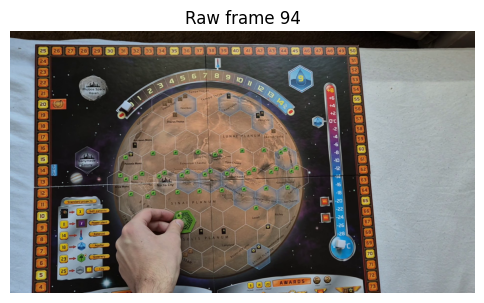

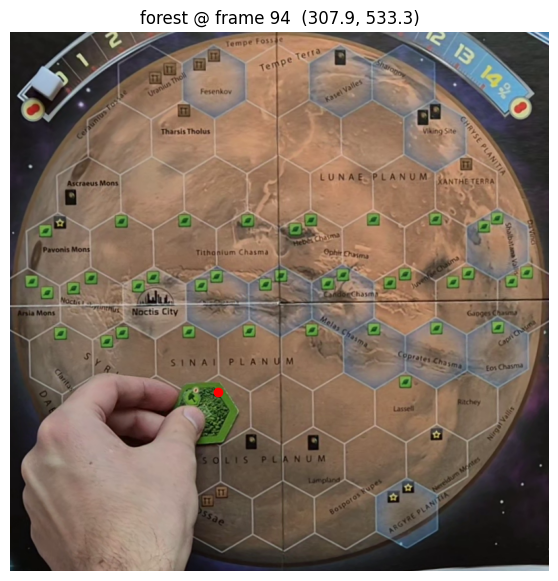

{'rc': (6, 2), 'color': 'orange', 't_sec': 10.53898888888889, 'bbox_map': (300, 545, 26, 20), 'tile_center_map_xy': (307.9201435678004, 533.3333333333333)}


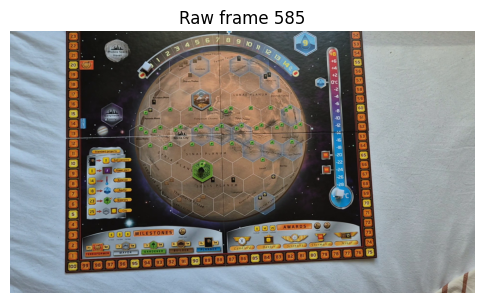

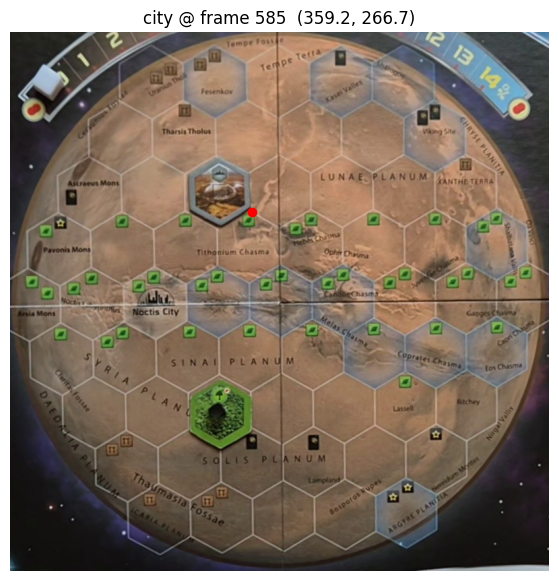

KeyboardInterrupt: 

In [ ]:
def draw_tile_from_event_frame(
    video_path,
    event,
    orb,
    board_template,
    map_template,
    board_size=(1200,1200),
    map_size=(800,800),
):
    # 1) Read final frame
    tile_type = event["tile"]
    frame = read_frame_at(video_path, event["frame_idx"])
    if frame is None:
        raise RuntimeError("Could not read event frame")
        plt.figure(figsize=(10, 3))

        plt.subplot(1, 4, 1)
        plt.title("ROI")
        plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title("keep")
        plt.imshow(keep_img, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.title("red")
        plt.imshow(red2d.astype(np.uint8) * 255, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.title("dark")
        plt.imshow(dark2d.astype(np.uint8) * 255, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")

        plt.suptitle(f"v80={v80:.1f} | red_ratio={red_ratio:.2f}", fontsize=10)
        plt.tight_layout()
        plt.show()
    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Raw frame {event['frame_idx']}")
    plt.axis("off")
    plt.show()

    map_topdown = cv2.warpPerspective(frame, event["H_frame_to_map"], (800, 800))

    x_map, y_map = event["pos_map_xy"]

    # 5) Forest position in map coords
    # If you trust the event's map coords already, you can keep them.
    # Here we recompute from the event's frame center (more “by-the-book”).
    x_map, y_map = event["pos_map_xy"]

    # 6) Draw map + point
    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(map_topdown, cv2.COLOR_BGR2RGB))
    plt.plot([x_map], [y_map], "ro")
    plt.title(f"{tile_type} @ frame {event['frame_idx']}  ({x_map:.1f}, {y_map:.1f})")
    plt.axis("off")
    plt.show()

    return (x_map, y_map), map_topdown



MW = 800
hex_size_px = MW / (9 * 1.5)
map_model = Map(hex_size=hex_size_px)

for e in events:
    pos_map_xy, map_img = draw_tile_from_event_frame(
        VIDEO_PATH,
        e,
        orb=orb,
        board_template=dataset["board"]["board"],
        map_template=dataset["regions"]["map"],
        board_size=(1200,1200),
        map_size=(800,800),
    )
    tile_type = e["tile"]
    x_map, y_map = pos_map_xy
    r, c = map_model.nearest_hex(x_map, y_map)
    map_model.place_tile(r, c, tile_type=tile_type)

    if tile_type == "ocean":
        continue

    tile_center = map_model.centers[(r, c)]

    cap_evt = cv2.VideoCapture(VIDEO_PATH)
    evt = find_first_cube_on_one_tile_colorblob(
        cap=cap_evt,
        orb=orb,
        dataset=dataset,
        r=r, c=c,
        tile_center_map_xy=tile_center,
        start_msec=int((e["time_sec"] * 1000 + 600)),  # start after placement motion
        crop_r=34,
        stable_frames=6,
        max_seconds=20,
        min_blob_area=80,
        black_v_max=75,
        debug=False
    )
    cap_evt.release()

    print(evt)
    if evt is not None:
        map_model.set_owner(r, c, evt['color'])

map_model.draw()


cube_evt: {'rc': (6, 3), 'color': 'black', 't_sec': 21.83458888888889, 'bbox_map': (387, 556, 36, 24), 'tile_center_map_xy': (410.56019142373384, 533.3333333333333)}
cube_evt: {'rc': (5, 4), 'color': 'black', 't_sec': 17.46768888888889, 'bbox_map': (425, 461, 29, 20), 'tile_center_map_xy': (461.8802153517006, 444.44444444444446)}
cube_evt: {'rc': (6, 3), 'color': 'black', 't_sec': 22.868000000000002, 'bbox_map': (408, 576, 11, 10), 'tile_center_map_xy': (410.56019142373384, 533.3333333333333)}
cube_evt: {'rc': (5, 3), 'color': 'black', 't_sec': 35.53537777777778, 'bbox_map': (371, 456, 18, 20), 'tile_center_map_xy': (359.2401674957671, 444.44444444444446)}


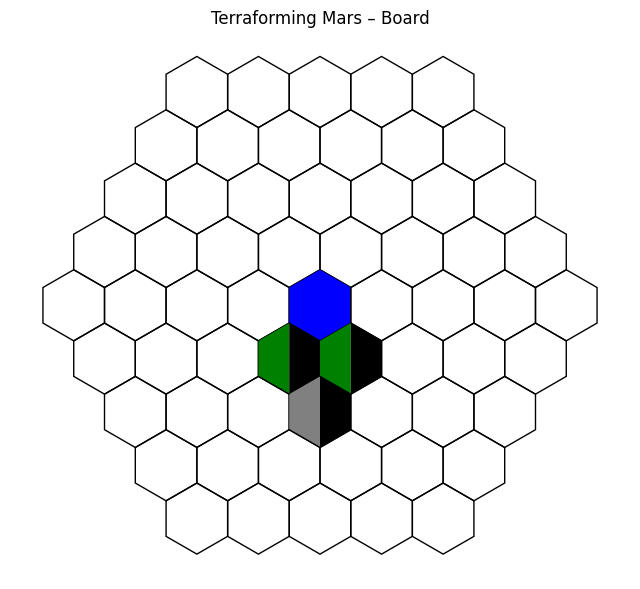

In [ ]:
# ==============================
# Tile-focused cube detector (appearance + temporal vote)
# Works in MAP coords (aligned_map 800x800), robust to shake (H smoothing) and finger (occlusion gate)
# Requires your existing:
#   - compute_H_frame_to_map(frame, orb, board_template, map_template, map_size=(800,800))
#   - warp_frame_to_map(frame, H, map_size=(800,800))
#   - Map.centers[(r,c)] in map pixel coords
# ==============================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque


def hex_mask_for_tile(H, W, center_xy, hex_radius_px):
    cx, cy = center_xy
    pts = []
    for k in range(6):
        ang = np.deg2rad(60 * k + 30)  # pointy-top
        x = cx + hex_radius_px * np.cos(ang)
        y = cy + hex_radius_px * np.sin(ang)
        pts.append([x, y])
    pts = np.int32(np.round(pts)).reshape(-1, 1, 2)

    m = np.zeros((H, W), np.uint8)
    cv2.fillConvexPoly(m, pts, 255)
    return m, pts


def bbox_from_mask(mask, pad=6):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(mask.shape[1] - 1, x1 + pad); y1 = min(mask.shape[0] - 1, y1 + pad)
    return x0, y0, (x1 - x0 + 1), (y1 - y0 + 1)


def occlusion_gate_hex(roi_bgr, roi_hex_mask,
                       max_cov_ratio=0.35,
                       bright_v_min=160,
                       sat_s_min=55):
    """
    Fast "finger/hand" rejector:
    - if a large fraction of hex pixels are bright+somewhat saturated, it's likely occluded.
    Tune max_cov_ratio ~0.25-0.45 depending on lighting.
    """
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    S = hsv[..., 1].astype(np.uint8)
    V = hsv[..., 2].astype(np.uint8)

    m = (roi_hex_mask > 0)
    if np.count_nonzero(m) < 50:
        return False

    bright = (V >= bright_v_min) & (S >= sat_s_min) & m
    cov = float(np.count_nonzero(bright)) / (float(np.count_nonzero(m)) + 1e-6)
    return cov > float(max_cov_ratio)


def find_cube_candidates_in_hex(roi_bgr, roi_hex_mask,
                               min_area=35,
                               max_area=900,
                               debug=False):
    """
    Returns list of candidates:
      [{"bbox":(x,y,w,h), "centroid":(cx,cy), "kind":"red"/"black", "score":float}, ...]
    ROI coords (not full map coords).
    """
    # Use LAB because it's much more stable on small blobs than HSV hue
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L = lab[..., 0].astype(np.int16)   # 0..255
    A = lab[..., 1].astype(np.int16)   # 0..255 (red/green axis around ~128)
    B = lab[..., 2].astype(np.int16)

    m = (roi_hex_mask > 0)
    if np.count_nonzero(m) < 50:
        return []

    # --- RED mask: high 'A' (reddish), moderate L, and inside hex ---
    # Typical printed map greens/browns won't spike A that hard.
    red_mask = (A >= 160) & (L >= 45) & m
    red_u8 = (red_mask.astype(np.uint8) * 255)

    # --- BLACK mask: low L inside hex, but avoid thin borders by morphology ---
    black_mask = (L <= 70) & m
    black_u8 = (black_mask.astype(np.uint8) * 255)

    # Clean up both
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    k5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    red_u8 = cv2.morphologyEx(red_u8, cv2.MORPH_OPEN, k3, iterations=1)
    red_u8 = cv2.morphologyEx(red_u8, cv2.MORPH_CLOSE, k5, iterations=1)

    black_u8 = cv2.morphologyEx(black_u8, cv2.MORPH_OPEN, k3, iterations=1)
    black_u8 = cv2.morphologyEx(black_u8, cv2.MORPH_CLOSE, k5, iterations=1)

    candidates = []

    def collect_from_mask(bin_u8, kind):
        cnts, _ = cv2.findContours(bin_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            area = float(cv2.contourArea(c))
            if area < float(min_area) or area > float(max_area):
                continue

            x, y, w, h = cv2.boundingRect(c)
            # cube-ish geometry gates
            ar = w / float(h + 1e-6)
            if ar < 0.65 or ar > 1.55:
                continue
            extent = area / float(w * h + 1e-6)
            if extent < 0.35:
                continue
            hull = cv2.convexHull(c)
            hull_area = float(cv2.contourArea(hull)) + 1e-6
            solidity = area / hull_area
            if solidity < 0.70:
                continue

            # ensure bbox is mostly inside hex
            x0 = max(0, x); y0 = max(0, y)
            x1 = min(roi_hex_mask.shape[1], x + w)
            y1 = min(roi_hex_mask.shape[0], y + h)
            inside = float(np.count_nonzero(roi_hex_mask[y0:y1, x0:x1] > 0))
            box_area = float((x1 - x0) * (y1 - y0) + 1e-6)
            if inside / box_area < 0.75:
                continue

            cx = x + 0.5 * w
            cy = y + 0.5 * h

            # simple score: prefer larger, more solid blobs
            score = area * solidity * extent
            candidates.append({
                "bbox": (int(x), int(y), int(w), int(h)),
                "centroid": (float(cx), float(cy)),
                "kind": kind,
                "score": float(score)
            })

    collect_from_mask(red_u8, "red")
    collect_from_mask(black_u8, "black")

    # If both exist, keep best few
    candidates.sort(key=lambda d: d["score"], reverse=True)

    if debug:
        vis = roi_bgr.copy()
        vis = cv2.bitwise_and(vis, vis, mask=roi_hex_mask)
        for i, cand in enumerate(candidates[:5]):
            x, y, w, h = cand["bbox"]
            cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 255), 2)
            cv2.putText(vis, f"{cand['kind']} {cand['score']:.0f}", (x, y - 3),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1, cv2.LINE_AA)
        plt.figure(figsize=(10, 3))
        plt.subplot(1, 3, 1); plt.title("roi"); plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off")
        plt.subplot(1, 3, 2); plt.title("red_u8"); plt.imshow(red_u8, cmap="gray"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.title("black_u8"); plt.imshow(black_u8, cmap="gray"); plt.axis("off")
        plt.tight_layout(); plt.show()

    return candidates


def vote_cube_over_time(cand_history,
                        required_hits=4,
                        window=8,
                        max_centroid_jitter=10.0):
    """
    cand_history: deque of either None or candidate dicts (best per frame).
    Returns (kind, bbox, centroid) or None
    """
    recent = list(cand_history)[-window:]
    hits = [c for c in recent if c is not None]
    if len(hits) < required_hits:
        return None

    # majority kind vote
    kinds = [c["kind"] for c in hits]
    kind = max(set(kinds), key=kinds.count)

    kind_hits = [c for c in hits if c["kind"] == kind]
    if len(kind_hits) < required_hits:
        return None

    # centroid jitter gate
    cx = np.array([c["centroid"][0] for c in kind_hits], dtype=np.float32)
    cy = np.array([c["centroid"][1] for c in kind_hits], dtype=np.float32)
    if (cx.max() - cx.min()) > max_centroid_jitter or (cy.max() - cy.min()) > max_centroid_jitter:
        return None

    # take best score instance as bbox representative
    best = max(kind_hits, key=lambda c: c["score"])
    return kind, best["bbox"], best["centroid"]


def find_cube_on_tile_after_event(
    video_path,
    event,                 # must contain at least frame_idx/time_sec for seeking; you already have this
    orb,
    dataset,
    r, c,
    tile_center_map_xy,
    map_size=(800, 800),
    crop_r=34,
    start_delay_ms=600,
    watch_seconds=12.0,
    H_smooth_alpha=0.25,
    required_hits=4,
    vote_window=8,
    min_area=35,
    debug=False
):
    """
    Tile-focused cube detection:
    - seek to event time + delay
    - per frame: compute H_frame_to_map, smooth, warp, crop hex ROI
    - reject occluded frames (finger)
    - find appearance-based red/black candidates
    - temporal vote (N hits in last M frames)
    Returns dict or None.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")

    # seek
    if "time_sec" in event:
        cap.set(cv2.CAP_PROP_POS_MSEC, int(event["time_sec"] * 1000 + start_delay_ms))
    else:
        # fallback: seek by frame index
        fps0 = cap.get(cv2.CAP_PROP_FPS) or 30.0
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, int(event["frame_idx"] + (start_delay_ms / 1000.0) * fps0)))

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    max_frames = int(watch_seconds * fps)

    cx_map, cy_map = float(tile_center_map_xy[0]), float(tile_center_map_xy[1])

    hex_radius_px = int(round(crop_r * 1.55))  # cube area + margin
    full_hex_mask, full_hex_pts = hex_mask_for_tile(
        H=map_size[1], W=map_size[0],
        center_xy=(cx_map, cy_map),
        hex_radius_px=hex_radius_px
    )
    bb = bbox_from_mask(full_hex_mask, pad=6)
    if bb is None:
        cap.release()
        return None
    x0, y0, w0, h0 = bb

    # crop-local mask/pts
    roi_hex_mask = full_hex_mask[y0:y0+h0, x0:x0+w0].copy()
    roi_hex_pts = full_hex_pts.copy()
    roi_hex_pts[:, 0, 0] -= x0
    roi_hex_pts[:, 0, 1] -= y0

    # homography smoothing
    H_prev = None

    # temporal candidate buffer
    cand_hist = deque(maxlen=max(vote_window, required_hits) + 2)

    for i in range(max_frames):
        ok, frame = cap.read()
        if not ok:
            break

        H_f2m = compute_H_frame_to_map(
            frame,
            orb,
            dataset["board"]["board"],
            dataset["regions"]["map"],
            map_size=map_size
        )
        if H_f2m is None:
            H_prev = None
            cand_hist.append(None)
            continue

        H = H_f2m / (H_f2m[2, 2] + 1e-9)
        if H_prev is None:
            H_prev = H
        else:
            H_prev = (1.0 - H_smooth_alpha) * H_prev + H_smooth_alpha * H
            H_prev = H_prev / (H_prev[2, 2] + 1e-9)

        aligned_map = warp_frame_to_map(frame, H_prev, map_size=map_size)

        roi = aligned_map[y0:y0+h0, x0:x0+w0].copy()

        # occlusion reject (finger)
        if occlusion_gate_hex(roi, roi_hex_mask, max_cov_ratio=0.35):
            cand_hist.append(None)
            continue

        candidates = find_cube_candidates_in_hex(
            roi, roi_hex_mask,
            min_area=min_area,
            max_area=900,
            debug=False
        )
        best = candidates[0] if candidates else None
        cand_hist.append(best)

        voted = vote_cube_over_time(
            cand_hist,
            required_hits=required_hits,
            window=vote_window,
            max_centroid_jitter=10.0
        )

        if debug and (i % 12 == 0):
            vis = cv2.bitwise_and(roi, roi, mask=roi_hex_mask)
            cv2.polylines(vis, [roi_hex_pts], True, (0, 255, 0), 2)
            if best is not None:
                x, y, w, h = best["bbox"]
                cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 255, 0), 2)
                cv2.putText(vis, best["kind"], (x, y - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2, cv2.LINE_AA)
            plt.figure(figsize=(6, 3))
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.title(f"tile ({r},{c}) frame+{i}  best={best['kind'] if best else None}")
            plt.axis("off")
            plt.show()

        if voted is not None:
            kind, bbox_roi, centroid_roi = voted

            # convert ROI bbox back to MAP coords
            bx, by, bw, bh = bbox_roi
            bbox_map = (int(bx + x0), int(by + y0), int(bw), int(bh))

            t_sec = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0
            cap.release()
            return {
                "rc": (r, c),
                "color": kind,  # "red" or "black"
                "t_sec": float(t_sec),
                "bbox_map": bbox_map,
                "tile_center_map_xy": (cx_map, cy_map)
            }

    cap.release()
    return None


# ==============================
# Testing / usage
# ==============================


# Assumes you already have:
#   - events: list of tile placement events with "tile", "time_sec" or "frame_idx", and "pos_map_xy"/(r,c)
#   - map_model with centers[(r,c)] in map pixels
#   - orb, dataset loaded (board/map templates)
#
# Example integration:
def test_cubes_for_events(events, map_model, orb, dataset, debug_one=False):
    out = []
    for idx, e in enumerate(events):
        tile_type = e["tile"]
        if tile_type == "ocean":
            continue

        # you already do this earlier: r,c from nearest_hex of the placement point
        r, c = e["rc"] if "rc" in e else map_model.nearest_hex(*e["pos_map_xy"])
        center = map_model.centers[(r, c)]

        evt = find_cube_on_tile_after_event(
            VIDEO_PATH,
            event=e,
            orb=orb,
            dataset=dataset,
            r=r, c=c,
            tile_center_map_xy=center,
            start_delay_ms=600,
            watch_seconds=12.0,
            crop_r=34,
            required_hits=4,
            vote_window=8,
            min_area=35,
            debug=(debug_one and idx == 0)
        )
        print("cube_evt:", evt)
        out.append(evt)
    return out


cube_events = test_cubes_for_events(events, map_model, orb, dataset, debug_one=True)
for ce in cube_events:
    if ce is None: continue
    r,c = ce["rc"]
    map_model.set_owner(r, c, ce["color"])
map_model.draw()


In [ ]:
print(events[4])

{'tile': 'city', 'frame_idx': 661, 'time_sec': 22.03651273313701, 'pos_map_xy': (410.56019142373384, 533.3333333333333), 'corners_map': array([[[404.21722, 507.51   ]],

       [[384.40662, 593.2226 ]],

       [[406.87692, 570.5391 ]],

       [[324.78638, 601.7992 ]]], dtype=float32), 'inliers': 8, 'good_matches': 17, 'area': 1890.3110054237768, 'stillness': 9.5249, 'appear': 25.973975, 'H_frame_to_map': array([[ 1.09654913e+00,  3.03406704e-02, -3.14862329e+02],
       [ 3.05706091e-02,  1.13124605e+00, -2.43960852e+02],
       [ 2.07033209e-05,  9.42273333e-05,  9.98714147e-01]]), 'cell_rc': (6, 3)}


In [ ]:
# ============================================================
# 1) MAP STABILIZATION (ECC)
# ============================================================
def make_center_mask(H, W, margin=70):
    m = np.zeros((H, W), np.uint8)
    m[margin:H-margin, margin:W-margin] = 255
    return m


def ecc_stabilize_map(prev_map_bgr, curr_map_bgr, mask=None):
    prev = cv2.cvtColor(prev_map_bgr, cv2.COLOR_BGR2GRAY)
    curr = cv2.cvtColor(curr_map_bgr, cv2.COLOR_BGR2GRAY)

    warp = np.eye(2, 3, dtype=np.float32)  # affine
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 40, 1e-4)

    try:
        cc, warp = cv2.findTransformECC(
            prev, curr, warp,
            cv2.MOTION_AFFINE,
            criteria,
            inputMask=mask
        )

        stabilized = cv2.warpAffine(
            curr_map_bgr,
            warp,
            (curr_map_bgr.shape[1], curr_map_bgr.shape[0]),
            flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP,
            borderMode=cv2.BORDER_REPLICATE
        )
        return stabilized, True, float(cc)
    except cv2.error:
        return curr_map_bgr, False, None


# ============================================================
# 2) MOTION GATE + BACKGROUND MODEL
# ============================================================
def global_motion_score(prev_gray, curr_gray, mask=None, step=16):
    a = prev_gray[::step, ::step].astype(np.float32)
    b = curr_gray[::step, ::step].astype(np.float32)

    if mask is None:
        return float(np.abs(a - b).mean())

    m = (mask[::step, ::step] > 0)
    if int(m.sum()) < 20:
        return float(np.abs(a - b).mean())

    return float(np.abs(a - b)[m].mean())


def bg_update_ema(bg_gray, curr_gray, alpha=0.02):
    if bg_gray is None:
        return curr_gray.copy()
    return cv2.addWeighted(bg_gray, 1.0 - alpha, curr_gray, alpha, 0.0)


# ============================================================
# 3) CANDIDATES FROM BACKGROUND SUBTRACTION
# ============================================================
def extract_cube_candidates(diff_gray, valid_mask=None,
                            diff_thresh=22,
                            min_area=20, max_area=1200):
    _, bw = cv2.threshold(diff_gray, diff_thresh, 255, cv2.THRESH_BINARY)

    if valid_mask is not None:
        bw = cv2.bitwise_and(bw, valid_mask)

    # MINIMAL morphology - just close small gaps
    # kernel = np.ones((3, 3), np.uint8)
    # bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel, iterations=1)

    cnts, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cands = []
    for c in cnts:
        area = float(cv2.contourArea(c))
        if area < min_area or area > max_area:
            continue

        x, y, w, h = cv2.boundingRect(c)
        if w <= 0 or h <= 0:
            continue

        aspect = w / float(h)
        if aspect < 0.45 or aspect > 2.3:
            continue

        fill = area / float(w * h)
        if fill < 0.22:
            continue

        M = cv2.moments(c)
        if M["m00"] <= 1e-6:
            continue

        cx = float(M["m10"] / M["m00"])
        cy = float(M["m01"] / M["m00"])

        cands.append({
            "contour": c,
            "area": area,
            "bbox": (int(x), int(y), int(w), int(h)),
            "center": (cx, cy),
        })

    cands.sort(key=lambda d: d["area"], reverse=True)
    return cands, bw


# ============================================================
# 4) COLOR CLASSIFICATION (RED vs BLACK) ON ROI
# ============================================================
def classify_cube_color(map_bgr, bbox_xywh):
    x, y, w, h = bbox_xywh
    H, W = map_bgr.shape[:2]

    x0 = max(0, x); y0 = max(0, y)
    x1 = min(W, x + w); y1 = min(H, y + h)
    roi = map_bgr[y0:y1, x0:x1]
    if roi.size == 0:
        return "unknown"

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    Hh = hsv[..., 0].astype(np.float32)
    Ss = hsv[..., 1].astype(np.float32)
    Vs = hsv[..., 2].astype(np.float32)

    m = (Ss > 40)
    if int(m.sum()) < 20:
        m = np.ones_like(Ss, dtype=bool)

    Hm = Hh[m]; Sm = Ss[m]; Vm = Vs[m]

    # black: dark
    if float(np.median(Vm)) < 70:
        return "black"

    # red: hue wraparound near 0 or 179 + sufficiently saturated
    red = ((Hm <= 10) | (Hm >= 170)) & (Sm > 60) & (Vm > 70)
    if float(red.mean()) > 0.10:
        return "red"

    return "unknown"


# ============================================================
# 5) YOUR SNAP FUNCTION (USE THIS INSTEAD OF TILE CENTERS)
# ============================================================
def make_snap_cell_fn_from_map(map_model):
    """
    snap_cell_fn(x, y) -> (r, c, cx, cy)
    """
    def snap_cell_fn(x, y):
        r, c = map_model.nearest_hex(x, y)
        cx, cy = map_model.centers[(r, c)]
        return r, c, cx, cy
    return snap_cell_fn


def cube_color_likelihood_mask(map_bgr):
    hsv = cv2.cvtColor(map_bgr, cv2.COLOR_BGR2HSV)
    H = hsv[..., 0]
    S = hsv[..., 1]
    V = hsv[..., 2]

    # black cube: VERY dark (stricter to avoid printed icons/shadows)
    black_like = (V < 55)

    # red cube: red hue, saturated, not too dark
    red_like = ((H <= 10) | (H >= 170)) & (S > 50) & (V > 40)

    mask = (black_like | red_like).astype(np.uint8) * 255
    return mask


def motion_changed_fraction(prev_gray, curr_gray, mask=None, thr=25, step=8):
    a = prev_gray[::step, ::step]
    b = curr_gray[::step, ::step]
    d = cv2.absdiff(a, b)

    if mask is not None:
        m = (mask[::step, ::step] > 0)
        if m.sum() < 10:
            return float((d > thr).mean())
        return float((d[m] > thr).mean())

    return float((d > thr).mean())
 


In [ ]:
def estimate_hex_radius_px_from_centers(map_model, sample_limit=200):
    """ Estimate hex 'radius' in pixels from map_model.centers (no hard-coded radius). For pointy-top hex grids: neighbor center distance ~= sqrt(3) * r => r ~= d / sqrt(3) """
    centers = list(map_model.centers.values())
    if len(centers) < 10:
        raise ValueError("Not enough centers to estimate hex radius")
    pts = np.array(centers, dtype=np.float32)
    if len(pts) > sample_limit:
        idx = np.random.choice(len(pts), sample_limit, replace=False)
        pts = pts[idx]
    dists = []
    for i in range(len(pts)):
        dx = pts[:, 0] - pts[i, 0]
        dy = pts[:, 1] - pts[i, 1]
        dd = np.sqrt(dx*dx + dy*dy)
        dd = dd[dd > 1e-3]
        if dd.size == 0:
            continue
        dists.append(float(np.min(dd)))
    if len(dists) < 10:
        raise ValueError("Could not estimate neighbor distance robustly")
    d_med = float(np.median(dists))
    r = d_med / np.sqrt(3.0)
    return float(r)

def hex_polygon_points(cx, cy, radius):
    """ Pointy-top hex (same orientation you used earlier): angles 30, 90, 150... """
    pts = []
    for k in range(6):
        ang = np.deg2rad(60 * k + 30)
        x = cx + radius * np.cos(ang)
        y = cy + radius * np.sin(ang)
        pts.append([x, y])
    return np.array(pts, dtype=np.float32)

def crop_tile_roi(map_bgr, center_xy, radius_px, pad=1.15):
    """ Crop a square ROI around the hex, return roi + (x0,y0) offset in map coords. """
    cx, cy = center_xy
    R = int(np.ceil(radius_px * pad))
    x0 = int(round(cx)) - R
    y0 = int(round(cy)) - R
    x1 = int(round(cx)) + R
    y1 = int(round(cy)) + R
    H, W = map_bgr.shape[:2]
    x0c = max(0, x0); y0c = max(0, y0)
    x1c = min(W, x1); y1c = min(H, y1)
    roi = map_bgr[y0c:y1c, x0c:x1c].copy()
    return roi, (x0c, y0c)

def hex_mask_in_roi(roi_shape_hw, center_xy_map, roi_offset_xy, radius_px, shrink=0.92):
    """ Create mask for hex area INSIDE the ROI. shrink slightly to avoid border lines between tiles. """
    H, W = roi_shape_hw
    x0, y0 = roi_offset_xy
    cx_map, cy_map = center_xy_map
    cx = cx_map - x0
    cy = cy_map - y0
    pts = hex_polygon_points(cx, cy, radius_px * shrink)
    pts_i = np.int32(np.round(pts)).reshape(-1, 1, 2)
    m = np.zeros((H, W), np.uint8)
    cv2.fillConvexPoly(m, pts_i, 255)
    return m, pts_i

def ecc_stabilize_roi(prev_roi_bgr, curr_roi_bgr, mask=None):
    """ Stabilize small ROI using ECC translation (fast & robust for shake). """
    prev = cv2.cvtColor(prev_roi_bgr, cv2.COLOR_BGR2GRAY)
    curr = cv2.cvtColor(curr_roi_bgr, cv2.COLOR_BGR2GRAY)
    warp = np.eye(2, 3, dtype=np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 1e-4)
    try:
        cc, warp = cv2.findTransformECC(
            prev, curr, warp, cv2.MOTION_TRANSLATION, criteria, inputMask=mask
        )
        stabilized = cv2.warpAffine(
            curr_roi_bgr, warp, (curr_roi_bgr.shape[1], curr_roi_bgr.shape[0]),
            flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP,
            borderMode=cv2.BORDER_REPLICATE
        )
        return stabilized, True, float(cc)
    except cv2.error:
        return curr_roi_bgr, False, None

def detect_cube_edges(roi_bgr, mask=None):
    """
    Detect cube edges using gradient-based edge detection.
    Cubes have strong edges from their 3D geometry.
    """
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    
    # Use Sobel to find strong gradients (edges)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    
    # Gradient magnitude
    gradient_mag = np.sqrt(sobelx**2 + sobely**2)
    gradient_mag = np.uint8(np.clip(gradient_mag, 0, 255))
    
    # Strong edges (cube boundaries)
    _, edge_mask = cv2.threshold(gradient_mag, 25, 255, cv2.THRESH_BINARY)
    
    if mask is not None:
        edge_mask = cv2.bitwise_and(edge_mask, mask)
    
    return edge_mask, gradient_mag

def cube_color_likelihood_mask_roi(roi_bgr):
    """
    Enhanced: combine color detection with edge detection.
    BUT be strict - only highlight areas that look like 3D cubes, not flat artwork.
    """
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    H = hsv[..., 0]
    S = hsv[..., 1]
    V = hsv[..., 2]
    
    # Color-based detection (more conservative)
    black_like = (V < 100) & (S < 80)
    red_like = ((H <= 12) | (H >= 168)) & (S > 65) & (V > 40)  # stricter S
    color_mask = (black_like | red_like).astype(np.uint8) * 255
    
    # Edge-based detection - but ONLY strong, closed edges (3D cube boundaries)
    edge_mask, _ = detect_cube_edges(roi_bgr)
    
    # KEY FIX: Only use edges where there's ALSO a diff from background
    # Artwork is static, cubes create temporal change
    # This will be combined with diff later in the pipeline
    
    # Dilate edges slightly
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))  # smaller
    edge_dilated = cv2.dilate(edge_mask, kernel, iterations=1)
    
    # Combine: require BOTH color match AND edges for artwork areas
    # For non-artwork areas, edges alone are ok
    combined = cv2.bitwise_or(color_mask, edge_dilated)
    
    return combined

def build_tile_allowed_mask(roi_shape_hw, center_xy_map, roi_offset_xy, hex_r, hex_shrink=0.90, inner_shrink=0.55):
    hex_mask, hex_pts = hex_mask_in_roi(
        roi_shape_hw, center_xy_map, roi_offset_xy, hex_r, shrink=hex_shrink
    )
    inner_mask, _ = hex_mask_in_roi(
        roi_shape_hw, center_xy_map, roi_offset_xy, hex_r, shrink=inner_shrink
    )
    allowed = cv2.bitwise_and(hex_mask, cv2.bitwise_not(inner_mask))
    return allowed, hex_mask, hex_pts

def cube_fill_ratios_in_bbox(roi_bgr, bbox):
    x, y, w, h = bbox
    patch = roi_bgr[y:y+h, x:x+w]
    if patch.size == 0:
        return 0.0, 0.0
    
    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    H = hsv[..., 0]
    S = hsv[..., 1]
    V = hsv[..., 2]
    
    red_like = (((H <= 12) | (H >= 168)) & (S > 65) & (V > 40))
    black_like = (V < 100) & (S < 80)
    
    red_ratio = float(np.mean(red_like))
    blk_ratio = float(np.mean(black_like))
    
    return red_ratio, blk_ratio

def patch_uniformity_score(roi_bgr, bbox):
    x, y, w, h = bbox
    patch = roi_bgr[y:y+h, x:x+w]
    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    V = hsv[...,2].astype(np.float32)
    return float(V.std())

def analyze_cube_geometry(roi_bgr, bbox):
    """
    Analyze the geometric properties - enhanced to distinguish cubes from artwork.
    Real cubes have:
    - Strong vertical/horizontal edges (isometric cube shape)
    - Consistent edge density in a compact region
    - NOT scattered/intricate patterns like artwork
    """
    x, y, w, h = bbox
    patch = roi_bgr[y:y+h, x:x+w]
    if patch.size == 0:
        return 0.0
    
    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    
    # Detect edges
    edges = cv2.Canny(gray, 25, 100)  # slightly higher thresholds
    edge_density = np.sum(edges > 0) / (w * h)
    
    # Detect corners
    corners = cv2.cornerHarris(gray.astype(np.float32), 2, 3, 0.04)
    corner_score = np.max(corners) if corners.size > 0 else 0.0
    
    # KEY: Check compactness - cubes have edges in a compact region
    # Artwork has scattered, intricate edges
    if edge_density > 0:
        # Find edge contours
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            # Largest contour should be substantial for a cube
            largest = max(contours, key=cv2.contourArea)
            contour_area = cv2.contourArea(largest)
            compactness = contour_area / (w * h)
            
            # Cubes: high compactness (solid blob)
            # Artwork: low compactness (scattered lines)
            if compactness < 0.10:  # too scattered, likely artwork
                return 0.0
    
    # Combined geometry score
    geometry_score = edge_density * 10 + (corner_score * 0.1)
    
    return float(geometry_score)

def is_likely_artwork_not_cube(roi_bgr, bbox, diff):
    """
    Reject ONLY when it behaves like static printed artwork.
    Key idea: artwork is (mostly) static -> low diff and low changed-pixel fraction.
    Cubes are new objects -> higher diff and a decent fraction of changed pixels.
    """
    x, y, w, h = bbox
    patch = roi_bgr[y:y+h, x:x+w]
    diff_patch = diff[y:y+h, x:x+w]

    if patch.size == 0:
        return True

    mean_diff = float(np.mean(diff_patch))
    chg_frac = float(np.mean(diff_patch >= 10))   # fraction of "really changed" pixels

    # 1) Only call it artwork if it's basically static
    if mean_diff < 7 and chg_frac < 0.06:
        return True

    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    variance = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    h_std = float(np.std(hsv[..., 0]))
    s_std = float(np.std(hsv[..., 1]))

    # 2) Intricate/colorful patterns count as artwork ONLY if also low-change
    if (variance > 1200) and (mean_diff < 9) and (chg_frac < 0.08):
        return True

    if (h_std > 35 or s_std > 55) and (mean_diff < 9) and (chg_frac < 0.08):
        return True

    # 3) Override: if a decent chunk changed, it’s almost certainly a placed object
    if chg_frac > 0.12 or mean_diff > 12:
        return False

    return False


def classify_cube_color(roi_bgr, bbox):
    """
    Enhanced classification - reject artwork false positives.
    """
    x, y, w, h = bbox
    patch = roi_bgr[y:y+h, x:x+w]
    if patch.size == 0:
        return "unknown"
    
    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    H = hsv[..., 0]
    S = hsv[..., 1]
    V = hsv[..., 2]
    
    mean_saturation = float(np.mean(S))
    mean_value = float(np.mean(V))
    
    # Count pixels matching each type
    red_mask = ((H <= 12) | (H >= 168)) & (S > 65) & (V > 40)
    black_mask = (V < 100) & (S < 80)
    
    red_ratio = float(np.mean(red_mask))
    black_ratio = float(np.mean(black_mask))
    
    geometry = analyze_cube_geometry(roi_bgr, bbox)
    
    # STRICTER thresholds to avoid artwork
    # Red: clearly red AND good geometry
    if mean_saturation > 60 and red_ratio > 0.18 and geometry > 0.5:
        return "red"
    
    # Black: low saturation + good geometry + not too dark (pure black background)
    if mean_saturation < 45 and mean_value > 30:  # not pure black background
        if geometry > 1.0 or mean_value < 65:
            return "black"
    
    # Borderline: very strong geometry required
    if geometry > 1.5:  # much stricter
        if black_ratio > red_ratio * 1.3:
            return "black"
        elif red_ratio > 0.20:
            return "red"
    
    return "unknown"

def _dbg_view(img, size_hw, cmap=False):
    """Make img BGR + same size. size_hw = (h,w). If img is None -> blank."""
    h, w = size_hw
    if img is None:
        return np.zeros((h, w, 3), np.uint8)

    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    if cmap:  # for diff
        img = cv2.applyColorMap(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.COLORMAP_JET)

    return cv2.resize(img, (w, h), interpolation=cv2.INTER_NEAREST)


def dbg_show(vis, *, diff=None, valid=None, edges=None, bw=None, title=None):
    """
    One debug window:
      top:   vis | diff | valid
      bottom:edges| bw  | blank
    """
    h, w = vis.shape[:2]
    sz = (h, w)

    v_vis   = _dbg_view(vis,   sz)
    v_diff  = _dbg_view(diff,  sz)
    v_valid = _dbg_view(valid, sz)
    v_edges = _dbg_view(edges, sz)
    v_bw    = _dbg_view(bw,    sz)
    blank   = np.zeros((h, w, 3), np.uint8)

    if title:
        cv2.putText(v_vis, title, (8, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

    top = np.hstack([v_vis, v_diff, v_valid])
    bot = np.hstack([v_edges, v_bw, blank])
    canvas = np.vstack([top, bot])

    cv2.imshow("debug", canvas)


def bg_update_ema_masked(bg_gray, curr_gray, alpha, bg_mask):
    # bg_mask: 255 where you allow learning (background), 0 where you forbid (foreground)
    m = (bg_mask.astype(np.float32) / 255.0)
    bg_f = bg_gray.astype(np.float32)
    cur_f = curr_gray.astype(np.float32)
    bg_f = bg_f * (1.0 - alpha * m) + cur_f * (alpha * m)
    return bg_f.astype(np.uint8)


def detect_first_cube_on_tile(
    video_path, orb, dataset, map_model, tile_rc,
    map_size=(800, 800),
    start_frame=0,
    hand_frac_thr=0.02,
    cooldown_frames=8,
    bg_alpha=0.03,
    init_bg_frames=30,
    diff_thresh=10,
    min_area=25,
    max_area=900,
    placed_need=5,
    debug=True,
    center_offset_frac=(0.0, 0.0),
):
    cap = cv2.VideoCapture(video_path)
    cv2.namedWindow("debug", cv2.WINDOW_NORMAL)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")
    
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    
    if tile_rc not in map_model.centers:
        raise ValueError(f"tile_rc {tile_rc} not in map_model.centers")
    
    tcx, tcy = map_model.centers[tile_rc]
    hex_r = estimate_hex_radius_px_from_centers(map_model)
    
    dxf, dyf = center_offset_frac
    tcx = float(tcx + dxf * hex_r)
    tcy = float(tcy + dyf * hex_r)
    
    prev_roi_gray = None
    bg_roi_gray = None
    bg_ready = 0
    bg_initialized = False
    cooldown = 0
    persist = 0
    last_color = None
    frame_idx = start_frame
    prev_roi_stable = None
    post_init_settle = 0
    POST_INIT_SETTLE_FRAMES = 10
    hand_hits = 0
    HAND_HITS_NEED = 10
    
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        
        H_f2m = compute_H_frame_to_map(
            frame, orb, dataset["board"]["board"],
            dataset["regions"]["map"], map_size=map_size
        )
        if H_f2m is None:
            continue
        
        aligned_map = warp_frame_to_map(frame, H_f2m, map_size=map_size)
        
        roi_raw, (x0, y0) = crop_tile_roi(aligned_map, (tcx, tcy), hex_r, pad=1.25)
        if roi_raw.size == 0:
            continue
        
        allowed_mask, hex_mask, hex_pts = build_tile_allowed_mask(
            roi_raw.shape[:2], (tcx, tcy), (x0, y0), hex_r,
            hex_shrink=0.90, inner_shrink=0.55
        )
        
        if prev_roi_stable is None:
            roi = roi_raw
            ok_ecc, cc = False, None
        else:
            roi, ok_ecc, cc = ecc_stabilize_roi(prev_roi_stable, roi_raw, mask=hex_mask)
            roi = roi_raw  # No stabilization
            ok_ecc, cc = False, None
        
        prev_roi_stable = roi
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        
        if prev_roi_gray is None:
            prev_roi_gray = roi_gray
            bg_roi_gray = roi_gray.copy()
            continue
        
        # Hand gate
        frac = motion_changed_fraction(prev_roi_gray, roi_gray, mask=hex_mask, thr=25, step=4)
        if frac > hand_frac_thr:
            hand_hits += 1
        else:
            hand_hits = 0

        if hand_hits >= HAND_HITS_NEED:
            cooldown = cooldown_frames
            hand_hits = 0
            persist = 0
            last_color = None
            prev_roi_gray = roi_gray
            if debug:
                vis = roi.copy()
                cv2.polylines(vis, [hex_pts], True, (0, 255, 0), 2)
                dbg_show(vis, title=f"HAND frac={frac:.3f}")
                cv2.waitKey(1)
            continue
        
        if cooldown > 0:
            cooldown -= 1
            persist = 0
            last_color = None
            prev_roi_gray = roi_gray
            
            if debug:
                vis = roi.copy()
                cv2.polylines(vis, [hex_pts], True, (0, 255, 0), 2)
                cv2.putText(vis, f"{cooldown}/{cooldown_frames}", (8, 22),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
                dbg_show(vis, title=f"{cooldown}/{cooldown_frames}")
                cv2.waitKey(1)
            continue
        
        # BG initialization
        if (not bg_initialized) and bg_ready < init_bg_frames:
            bg_roi_gray = bg_update_ema(bg_roi_gray, roi_gray, alpha=bg_alpha)
            bg_ready += 1
            if bg_ready >= init_bg_frames:
                bg_initialized = True
                post_init_settle = POST_INIT_SETTLE_FRAMES
            prev_roi_gray = roi_gray
            
            if debug:
                vis = roi.copy()
                cv2.polylines(vis, [hex_pts], True, (0, 255, 0), 2)
                cv2.putText(vis, f"BG init {bg_ready}/{init_bg_frames}", (8, 22),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
                dbg_show(vis, title=f"BG init {bg_ready}/{init_bg_frames}")
                cv2.waitKey(1)
            continue
        
        if post_init_settle > 0:
            bg_roi_gray = bg_update_ema(bg_roi_gray, roi_gray, alpha=bg_alpha)
            post_init_settle -= 1
            persist = 0
            last_color = None
            prev_roi_gray = roi_gray
            
            if debug:
                vis = roi.copy()
                cv2.polylines(vis, [hex_pts], True, (0, 255, 0), 2)
                cv2.putText(vis, f"POST-INIT settle {post_init_settle}", (8, 22),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
                dbg_show(vis, title=f"POST-INIT settle {post_init_settle}")
                cv2.waitKey(1)
            continue
        
        # Diff and blob detection
        diff = cv2.absdiff(roi_gray, bg_roi_gray)

        # Use ADAPTIVE thresholding to find local concentrations
        # This ignores scattered noise and finds compact blobs
        diff_blur = cv2.GaussianBlur(diff, (5, 5), 0)

        # Threshold to find only significant local peaks
        _, fg = cv2.threshold(diff_blur, diff_thresh + 5, 255, cv2.THRESH_BINARY)
        fg = cv2.bitwise_and(fg, hex_mask)

        # Aggressive morphology to eliminate scattered pixels
        # Keep only solid, compact regions
        k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, k_open, iterations=2)  # Kill scattered noise

        k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (4, 4))
        fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, k_close, iterations=2)  # Solidify blobs

        valid = fg
                
        cands, bw = extract_cube_candidates(
            diff, valid_mask=valid,
            diff_thresh=diff_thresh,
            min_area=min_area,
            max_area=max_area
        )
        
        if len(cands) == 0:
            # ONLY update background if diff is genuinely low everywhere
            max_diff_in_hex = np.max(diff[hex_mask > 0])
            
            if max_diff_in_hex < 30:  # Nothing significant changed
                bg_roi_gray = bg_update_ema(bg_roi_gray, roi_gray, alpha=bg_alpha)
            
            persist = 0
            last_color = None
            prev_roi_gray = roi_gray
            
            if debug:
                dbg_show(vis, diff=diff, valid=valid, bw=bw, 
                        title=f"no candidate (max_diff={max_diff_in_hex:.0f})")
                cv2.waitKey(1)
            continue
                
        # Score blobs by compactness + area + geometry
        def score(c):
            x, y, w, h = c["bbox"]
            aspect = min(w, h) / max(w, h)
            #geom = analyze_cube_geometry(roi, c["bbox"])
            #return c["area"] * aspect * (1.0 + geom)
            return c["area"] * aspect
        
        best = max(cands, key=score)
        bx, by, bwid, bhei = best["bbox"]
        
        # NEW: Check if this is artwork, not a cube
        # if is_likely_artwork_not_cube(roi, best["bbox"], diff):
        #     # DO NOT update background here (it will absorb the cube/artifact)
        #     persist = 0
        #     last_color = None
        #     prev_roi_gray = roi_gray

        #     if debug:
        #         vis = roi.copy()
        #         cv2.polylines(vis, [hex_pts], True, (0, 255, 0), 2)
        #         cv2.rectangle(vis, (bx, by), (bx + bwid, by + bhei), (0, 165, 255), 2)
        #         cv2.putText(vis, "ARTWORK? (no BG update)", (8, 22),
        #                     cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)
        #         #cv2.imshow("tile_roi", vis)
        #         dbg_show(vis, diff=diff, title="ARTWORK? (no BG update)")
        #         cv2.waitKey(1)
        #     continue
        
        # Get diagnostic info
        patch = roi[by:by+bhei, bx:bx+bwid]
        hsv_patch = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
        mean_sat = float(np.mean(hsv_patch[..., 1]))
        mean_val = float(np.mean(hsv_patch[..., 2]))
        mean_diff = float(np.mean(diff[by:by+bhei, bx:bx+bwid]))
        
        red_ratio, blk_ratio = cube_fill_ratios_in_bbox(roi, best["bbox"])
        geometry_score = analyze_cube_geometry(roi, best["bbox"])
        
        # STRICTER filters
        if red_ratio < 0.18 and blk_ratio < 0.18:
            bg_roi_gray = bg_update_ema(bg_roi_gray, roi_gray, alpha=bg_alpha)
            persist = 0
            last_color = None
            prev_roi_gray = roi_gray
            continue
        
        # Require minimum diff from background (not static artwork)
        if mean_diff < 5:
            bg_roi_gray = bg_update_ema(bg_roi_gray, roi_gray, alpha=bg_alpha)
            persist = 0
            last_color = None
            prev_roi_gray = roi_gray
            continue
        
        # Geometry must be reasonable
        if geometry_score < 0.3:
            continue
        
        color = classify_cube_color(roi, best["bbox"])
        
        if color == last_color:
            persist += 1
        else:
            last_color = color
            persist = 1
        
        prev_roi_gray = roi_gray
        
        if debug:
            vis = roi.copy()
            cv2.polylines(vis, [hex_pts], True, (0, 255, 0), 2)
            cv2.rectangle(vis, (bx, by), (bx + bwid, by + bhei), (255, 0, 0), 2)
            cv2.putText(vis, f"{color} p={persist}/{placed_need}",
                       (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            cv2.putText(vis, f"S={mean_sat:.0f} V={mean_val:.0f} diff={mean_diff:.1f}",
                       (8, 44), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            cv2.putText(vis, f"geom={geometry_score:.2f}",
                       (8, 66), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            #cv2.imshow("tile_roi", vis)
            
            # Show edge detection
            edge_mask, _ = detect_cube_edges(roi, mask=hex_mask)
            #cv2.imshow("edges", edge_mask)
            #cv2.imshow("valid_mask", valid)
            
            bw_vis = cv2.cvtColor(bw, cv2.COLOR_GRAY2BGR)
            cv2.drawContours(bw_vis, [best["contour"]], -1, (0, 0, 255), 2)
            #cv2.imshow("tile_bw", bw_vis)

            dbg_show(vis, diff=diff, valid=valid, edges=edge_mask, bw=bw_vis)
            
            k = cv2.waitKey(1) & 0xFF
            if k == ord('q'):
                break
            if k == ord('p'):
                while True:
                    k = cv2.waitKey(50) & 0xFF
                    if k == ord('p'):
                        break
                    if k == ord('q'):
                        break

        if persist >= placed_need and color in ("red", "black"):
            t_sec = frame_idx / float(fps)
            evt = {
                "frame": int(frame_idx),
                "t_sec": float(t_sec),
                "tile_rc": tuple(tile_rc),
                "tile_center_map_xy": (float(tcx), float(tcy)),
                "bbox_roi": best["bbox"],
                "color": color
            }
            cap.release()
            if debug:
                import matplotlib.pyplot as plt
                
                # Prepare final detection state visualizations
                final_vis = roi.copy()
                cv2.polylines(final_vis, [hex_pts], True, (0, 255, 0), 2)
                cv2.rectangle(final_vis, (bx, by), (bx + bwid, by + bhei), (255, 0, 0), 3)
                cv2.putText(final_vis, f"DETECTED: {color.upper()}", (8, 22),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                
                # Show aligned map with detected tile highlighted
                map_vis = aligned_map.copy()
                hex_pts_map = hex_polygon_points(tcx, tcy, hex_r * 0.90)
                hex_pts_map_i = np.int32(np.round(hex_pts_map)).reshape(-1, 1, 2)
                cv2.polylines(map_vis, [hex_pts_map_i], True, (0, 255, 0), 3)
                cv2.putText(map_vis, f"{color} at {tile_rc}", 
                        (int(tcx) - 50, int(tcy) - int(hex_r) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
                
                # Diff visualization
                diff_colored = cv2.applyColorMap(diff, cv2.COLORMAP_JET)
                
                # Blob visualization
                bw_vis = cv2.cvtColor(bw, cv2.COLOR_GRAY2BGR)
                cv2.drawContours(bw_vis, [best["contour"]], -1, (0, 255, 0), 2)
                cv2.rectangle(bw_vis, (bx, by), (bx + bwid, by + bhei), (0, 0, 255), 2)
                
                # Edge visualization
                edge_mask, _ = detect_cube_edges(roi, mask=hex_mask)
                edge_vis = cv2.cvtColor(edge_mask, cv2.COLOR_GRAY2BGR)
                
                # Valid mask visualization
                valid_vis = cv2.cvtColor(valid, cv2.COLOR_GRAY2BGR)
                
                # Convert BGR to RGB for matplotlib
                final_vis_rgb = cv2.cvtColor(final_vis, cv2.COLOR_BGR2RGB)
                map_vis_rgb = cv2.cvtColor(map_vis, cv2.COLOR_BGR2RGB)
                diff_rgb = cv2.cvtColor(diff_colored, cv2.COLOR_BGR2RGB)
                bw_vis_rgb = cv2.cvtColor(bw_vis, cv2.COLOR_BGR2RGB)
                edge_vis_rgb = cv2.cvtColor(edge_vis, cv2.COLOR_BGR2RGB)
                valid_vis_rgb = cv2.cvtColor(valid_vis, cv2.COLOR_BGR2RGB)
                
                # Create figure with subplots
                fig, axes = plt.subplots(2, 3, figsize=(15, 10))
                fig.suptitle(f'Cube Detection: {color.upper()} at tile {tile_rc} (frame {frame_idx}, t={t_sec:.2f}s)', 
                            fontsize=16, fontweight='bold')
                
                # Row 1: Map and ROI views
                axes[0, 0].imshow(map_vis_rgb)
                axes[0, 0].set_title('Full Map with Detected Tile')
                axes[0, 0].axis('off')
                
                axes[0, 1].imshow(final_vis_rgb)
                axes[0, 1].set_title(f'ROI: {color} cube detected')
                axes[0, 1].axis('off')
                
                axes[0, 2].imshow(diff_rgb)
                axes[0, 2].set_title('Diff from Background')
                axes[0, 2].axis('off')
                
                # Row 2: Detection pipeline
                axes[1, 0].imshow(valid_vis_rgb)
                axes[1, 0].set_title('Valid Mask (color + edges)')
                axes[1, 0].axis('off')
                
                axes[1, 1].imshow(edge_vis_rgb)
                axes[1, 1].set_title('Edge Detection')
                axes[1, 1].axis('off')
                
                axes[1, 2].imshow(bw_vis_rgb)
                axes[1, 2].set_title('Blob Detection')
                axes[1, 2].axis('off')
                
                # Add text with detection stats
                stats_text = (
                    f"Detection Stats:\n"
                    f"Color: {color}\n"
                    f"Tile: {tile_rc}\n"
                    f"Mean Saturation: {mean_sat:.1f}\n"
                    f"Mean Value: {mean_val:.1f}\n"
                    f"Geometry Score: {geometry_score:.2f}\n"
                    f"Red Ratio: {red_ratio:.2f}\n"
                    f"Black Ratio: {blk_ratio:.2f}\n"
                    f"Persist Count: {persist}/{placed_need}"
                )
                fig.text(0.02, 0.02, stats_text, fontsize=10, family='monospace',
                        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                
                plt.tight_layout()
                plt.show()
                
                cv2.destroyAllWindows()
            return evt



    cap.release()
    if debug:
        cv2.destroyAllWindows()
    return None

In [ ]:
cv2.destroyAllWindows()
evt = detect_first_cube_on_tile(
    video_path=VIDEO_PATH,
    orb=orb,
    dataset=dataset,
    map_model=map_model,
    tile_rc=(6, 3),          # <-- your tile
    start_frame=666,         # <-- near 12s you mentioned
    diff_thresh=7,
    placed_need=4,
    debug=True,
    center_offset_frac=(-0.10, +0.40),
    cooldown_frames=3,
    min_area=20
)
print("EVENT:", evt)



qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/pipi/fer/erasmus/computer vision/CV_Project2/.venv/lib/python3.13/site-packages/cv2/qt/plugins"


EVENT: None


In [ ]:
cv2.destroyAllWindows()


{'tile': 'forest', 'frame_idx': 337, 'time_sec': 11.234954298134904, 'pos_map_xy': (461.8802153517006, 444.44444444444446), 'corners_map': array([[[355.7001 , 415.09366]],

       [[488.36496, 416.75314]],

       [[492.08994, 513.21216]],

       [[414.34976, 538.39923]]], dtype=float32), 'inliers': 14, 'good_matches': 15, 'area': 11926.774782355875, 'stillness': 9.600575, 'appear': 13.4168, 'H_frame_to_map': array([[ 1.09636134e+00,  6.67754284e-03, -3.39955186e+02],
       [ 5.31669446e-02,  1.12604317e+00, -2.69091625e+02],
       [ 2.45182383e-05,  9.13507062e-05,  9.95774135e-01]]), 'cell_rc': (5, 4)}


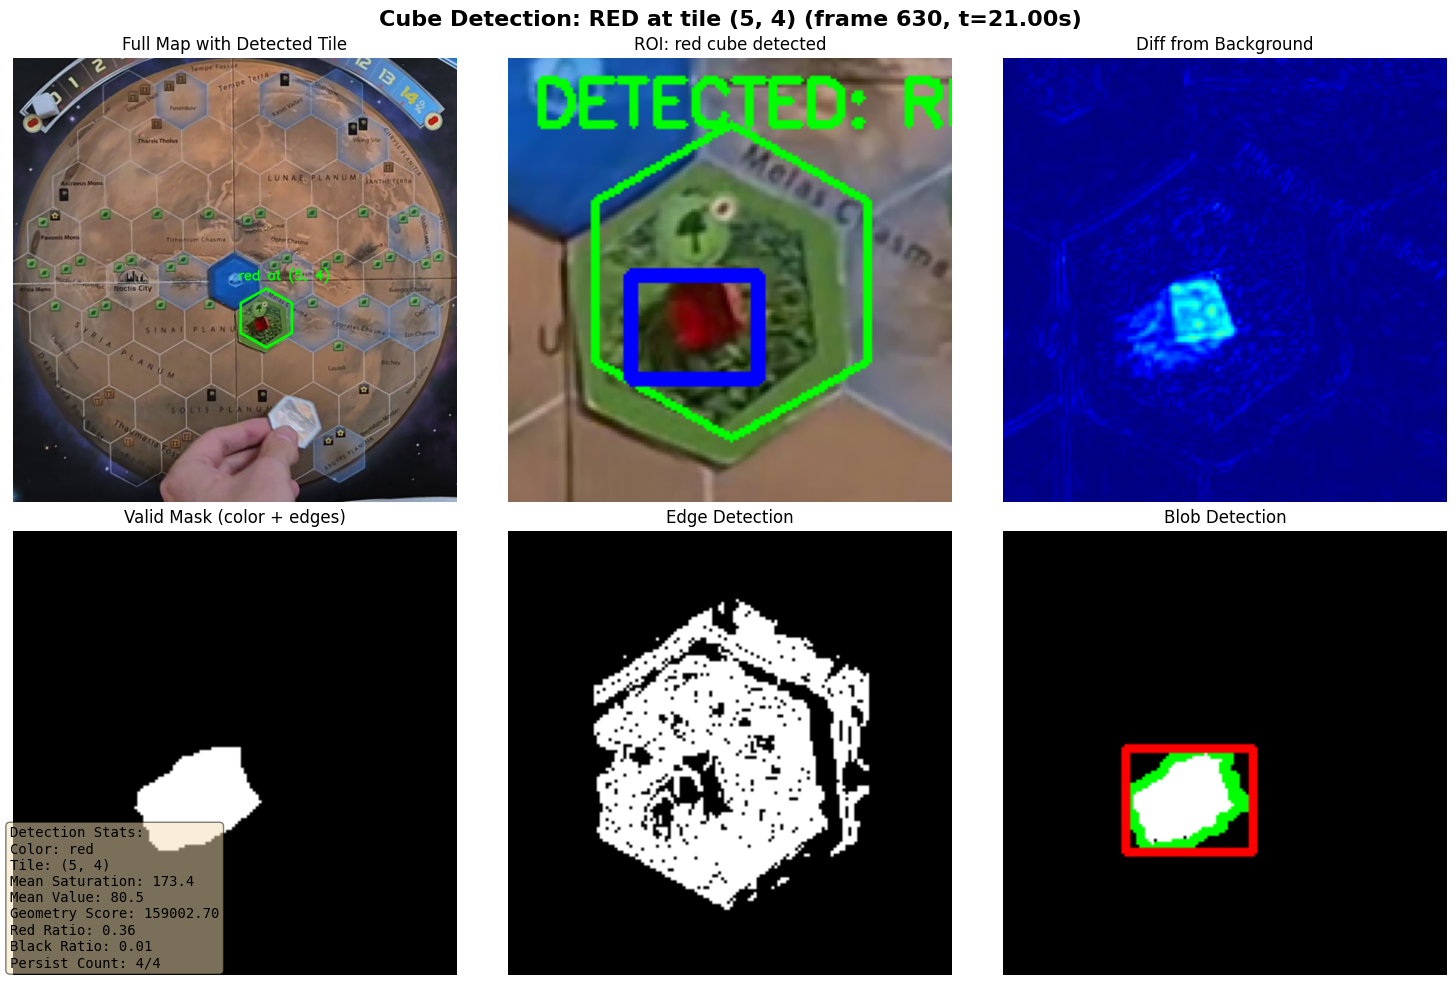

{'frame': 630, 't_sec': 21.003030290281867, 'tile_rc': (5, 4), 'tile_center_map_xy': (455.95429134301037, 468.1481404792055), 'bbox_roi': (41, 73, 43, 35), 'color': 'red'}
{'tile': 'city', 'frame_idx': 661, 'time_sec': 22.03651273313701, 'pos_map_xy': (410.56019142373384, 533.3333333333333), 'corners_map': array([[[404.21722, 507.51   ]],

       [[384.40662, 593.2226 ]],

       [[406.87692, 570.5391 ]],

       [[324.78638, 601.7992 ]]], dtype=float32), 'inliers': 8, 'good_matches': 17, 'area': 1890.3110054237768, 'stillness': 9.5249, 'appear': 25.973975, 'H_frame_to_map': array([[ 1.09654913e+00,  3.03406704e-02, -3.14862329e+02],
       [ 3.05706091e-02,  1.13124605e+00, -2.43960852e+02],
       [ 2.07033209e-05,  9.42273333e-05,  9.98714147e-01]]), 'cell_rc': (6, 3)}


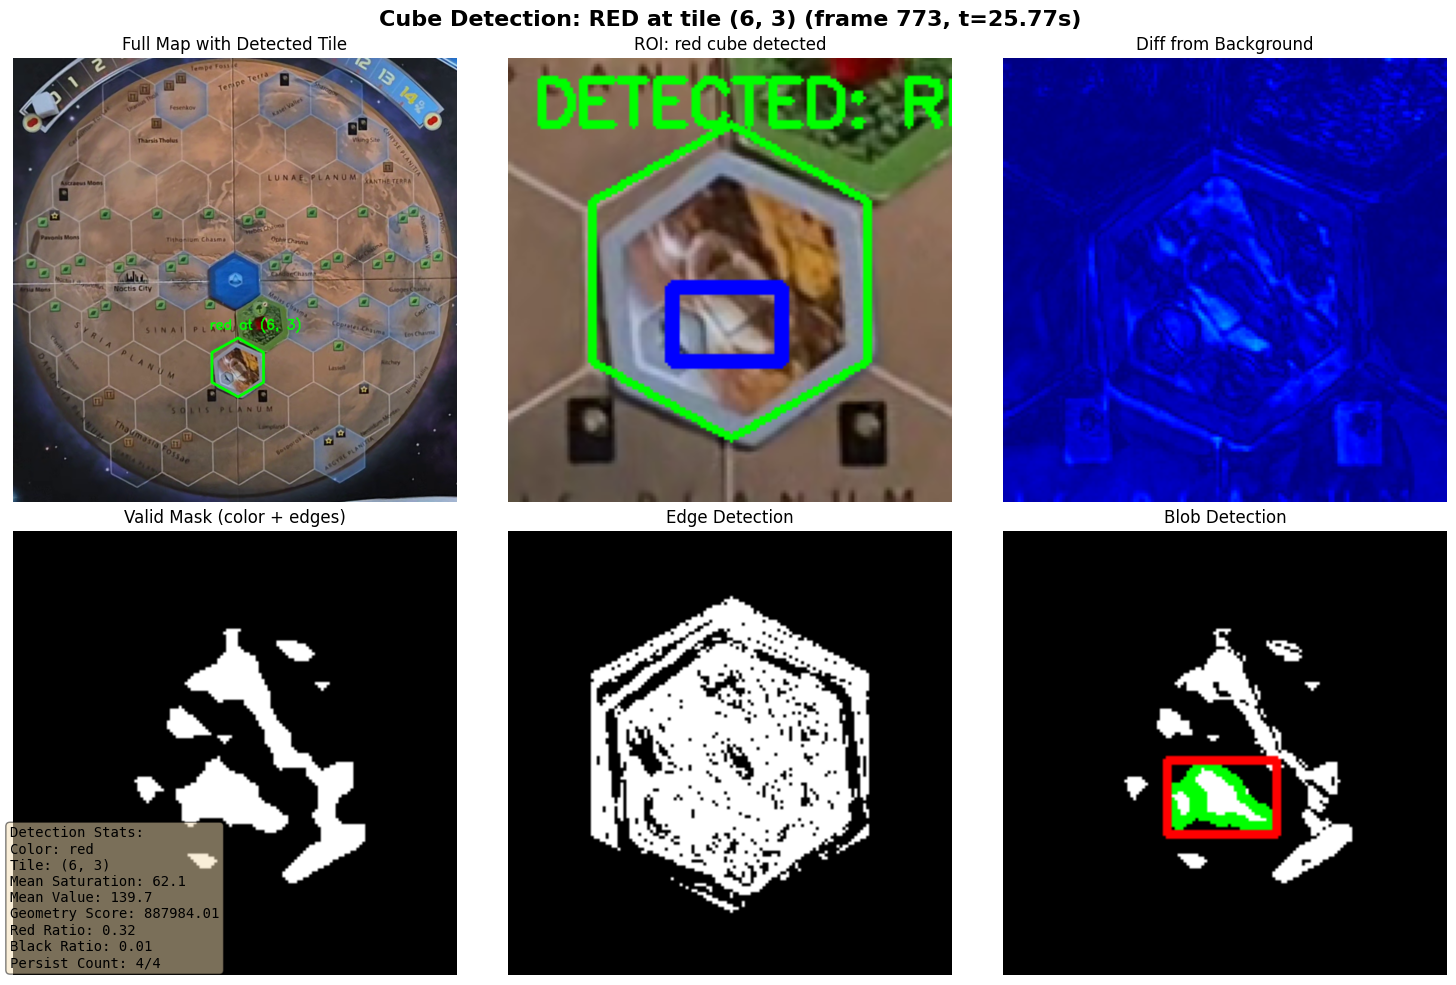

{'frame': 773, 't_sec': 25.770384784742674, 'tile_rc': (6, 3), 'tile_center_map_xy': (404.6342674150436, 557.0370293680943), 'bbox_roi': (55, 77, 37, 25), 'color': 'red'}
{'tile': 'forest', 'frame_idx': 998, 'time_sec': 33.27146703127191, 'pos_map_xy': (359.2401674957671, 444.44444444444446), 'corners_map': array([[[278.4739 , 571.6655 ]],

       [[259.98053, 462.97107]],

       [[347.04108, 436.30292]],

       [[391.38303, 510.10638]]], dtype=float32), 'inliers': 12, 'good_matches': 13, 'area': 10509.459980616346, 'stillness': 9.245925, 'appear': 18.8311, 'H_frame_to_map': array([[ 1.04003373e+00,  4.80346724e-03, -2.63613283e+02],
       [ 4.30096848e-02,  1.07132765e+00, -2.77157149e+02],
       [ 1.25290740e-05,  8.00945190e-05,  9.97991401e-01]]), 'cell_rc': (5, 3)}


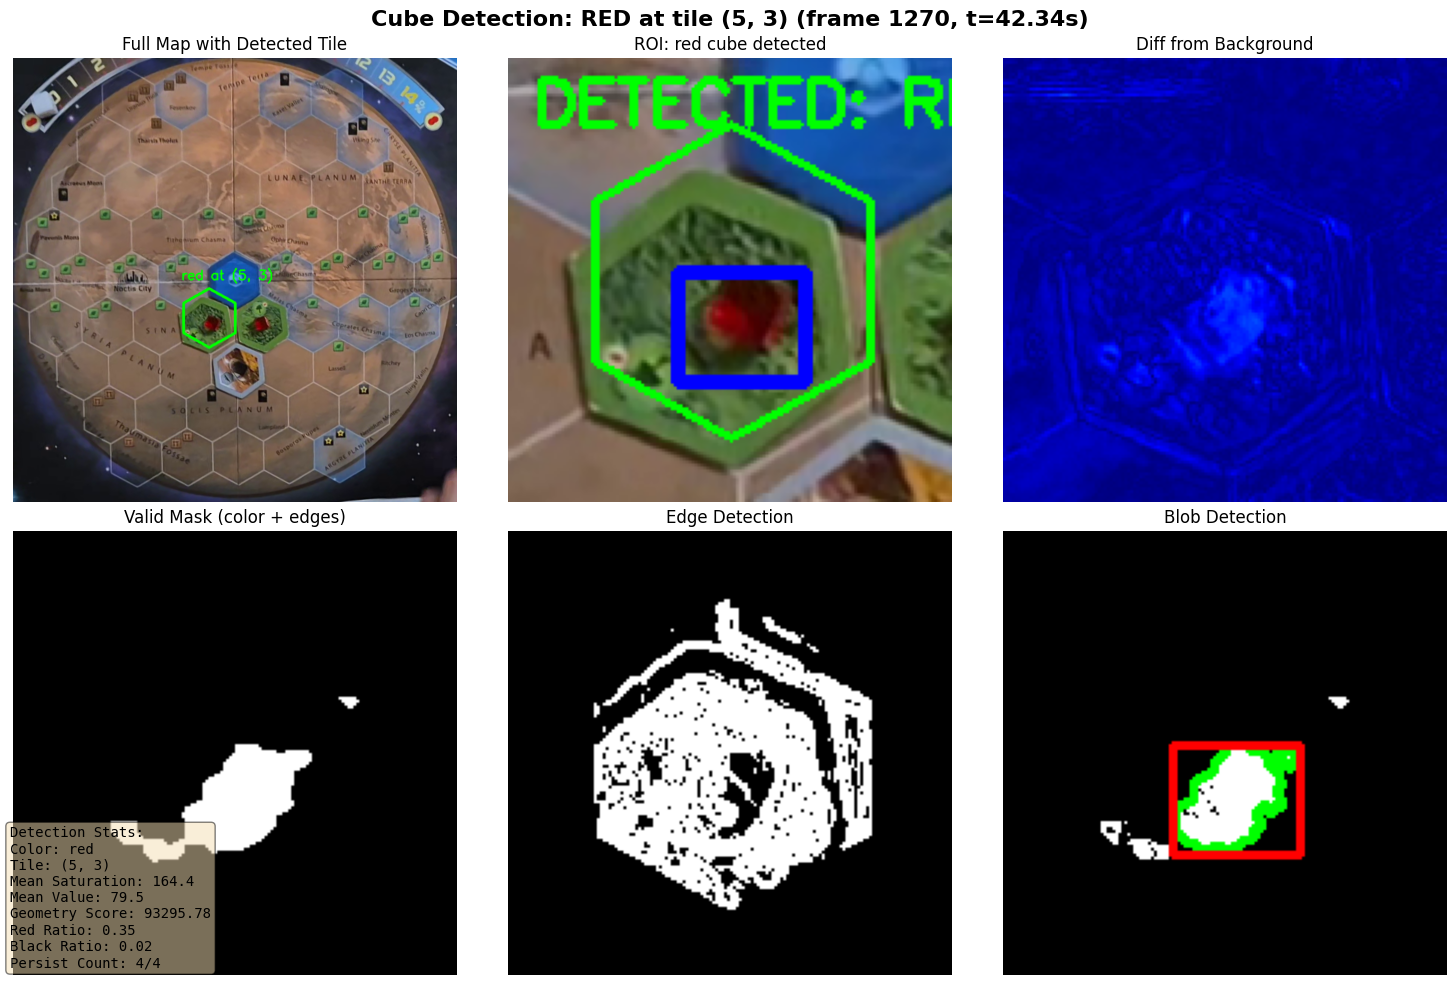

{'frame': 1270, 't_sec': 42.33944201374281, 'tile_rc': (5, 3), 'tile_center_map_xy': (353.31424348707685, 468.1481404792055), 'bbox_roi': (57, 72, 43, 37), 'color': 'red'}


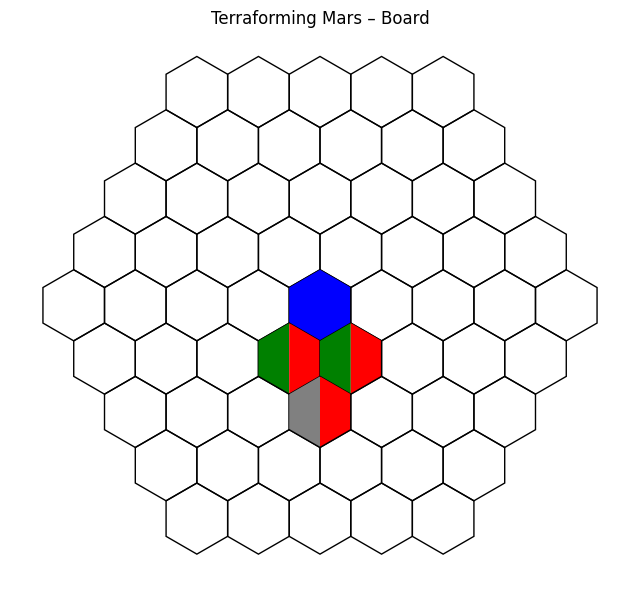

In [ ]:
for evt in events[3:]:
    if evt['tile'] == 'ocean':
        continue

    print(evt)
    r,c = evt['cell_rc']
    
    cube_evt = detect_first_cube_on_tile(
       video_path=VIDEO_PATH,
        orb=orb,
        dataset=dataset,
        map_model=map_model,
        tile_rc=(r, c),         
        start_frame=evt['frame_idx'],         
        diff_thresh=12,
        placed_need=4,
        debug=True,
        center_offset_frac=(-0.10, +0.40),
        cooldown_frames=3,
        min_area=8
    )

    print(cube_evt)
    if cube_evt is not None:
        map_model.set_owner(r, c, cube_evt['color'])

map_model.draw()

In [ ]:
import cv2
import numpy as np
from collections import deque


# -----------------------------
# SETTINGS (template-coords!)
# -----------------------------
BOARD_SIZE = (1200, 1200)

# IMPORTANT: these y values must be in the STABILIZED thermo_patch coordinates
CALIB = {
    "y_top_tick_frac": 45.0 / 770.0,      # was 45
    "y_bottom_tick_frac": 0.93,  # was 770  (== 1.0)
    "t_min": -30,
    "t_max": 8,
    "step": 2,
}


# anchor inside cube bbox to read temperature:
# 0.0 = top edge, 0.5 = center. Usually 0.15–0.30 works best.
Y_ANCHOR_FRAC = 0.75

VOTE_WINDOW = 14
VOTE_NEED   = 9


# -----------------------------
# STABILIZE THERMO PATCH
# -----------------------------
def warp_frame_to_board(frame_bgr, H_frame_to_board, board_size):
    BW, BH = board_size
    return cv2.warpPerspective(frame_bgr, H_frame_to_board, (BW, BH))


def warp_board_to_temp_template(board_topdown_bgr, temp_template, H_temp_to_board):
    """
    temp_template.img is grayscale template (th,tw)
    H_temp_to_board maps template -> board_topdown
    Returns thermo_patch in TEMPLATE coords => stabilized.
    """
    th, tw = temp_template.img.shape[:2]
    H_board_to_temp = np.linalg.inv(H_temp_to_board)
    patch = cv2.warpPerspective(board_topdown_bgr, H_board_to_temp, (tw, th))
    return patch


# -----------------------------
# WHITE CUBE DETECTOR (bbox)
# -----------------------------
def detect_white_temp_cube_bbox(thermo_patch_bgr, debug=False):
    """
    Returns: (bbox_xywh, center_xy, vis, dbg)
      bbox_xywh: (x,y,w,h) or None
      dbg: {"white":..., "white_open":...}
    """
    h, w = thermo_patch_bgr.shape[:2]
    hsv = cv2.cvtColor(thermo_patch_bgr, cv2.COLOR_BGR2HSV)
    S = hsv[..., 1]
    V = hsv[..., 2]

    # white-ish: low saturation + high value
    white = ((S < 85) & (V > 150)).astype(np.uint8) * 255

    # opening kills thin digits more than the cube
    k9 = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    k7 = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    white_open = cv2.morphologyEx(white, cv2.MORPH_OPEN, k9, iterations=1)
    white_open = cv2.morphologyEx(white_open, cv2.MORPH_CLOSE, k7, iterations=1)

    n, labels, stats, centroids = cv2.connectedComponentsWithStats(white_open, connectivity=8)

    best = None
    best_score = -1e18

    for i in range(1, n):
        x, y, ww, hh, area = stats[i]
        if area < 120 or area > 6000:
            continue

        ar = ww / float(hh + 1e-6)
        if ar < 0.65 or ar > 1.55:
            continue

        mask_i = (labels == i).astype(np.uint8) * 255
        cnts, _ = cv2.findContours(mask_i, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        c = max(cnts, key=cv2.contourArea)
        area_c = float(cv2.contourArea(c))
        if area_c < 120:
            continue

        peri = float(cv2.arcLength(c, True))
        compact = 4.0 * np.pi * area_c / (peri * peri + 1e-6)  # 0..1

        extent = area_c / float(ww * hh + 1e-6)               # filled bbox ratio
        square_pen = abs(ar - 1.0)

        # emphasize "filled square blob"
        score = (3.0 * extent) + (2.0 * compact) + (0.0005 * area_c) - (1.5 * square_pen)

        if score > best_score:
            best_score = score
            best = (int(x), int(y), int(ww), int(hh), float(centroids[i][0]), float(centroids[i][1]))

    dbg = {"white": white, "white_open": white_open}

    if best is None:
        return None, None, (thermo_patch_bgr.copy() if debug else None), (dbg if debug else {})

    x, y, ww, hh, cx, cy = best
    bbox = (x, y, ww, hh)
    center = (cx, cy)

    if not debug:
        return bbox, center, None, {}

    vis = thermo_patch_bgr.copy()
    cv2.rectangle(vis, (x, y), (x + ww, y + hh), (0, 255, 0), 2)
    cv2.circle(vis, (int(cx), int(cy)), 4, (0, 0, 255), -1)
    cv2.putText(vis, "CUBE", (x, max(0, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    return bbox, center, vis, dbg


# -----------------------------
# BBOX -> TEMPERATURE
# -----------------------------
def temp_from_cube_bbox(bbox_xywh, calib, y_anchor_frac=0.20):
    if bbox_xywh is None:
        return None, None

    x, y, w, h = bbox_xywh
    y_ref = float(y) + float(h) * float(y_anchor_frac)  # use near TOP of cube

    H = float(calib["_patch_h"])  # injected per-frame
    y0 = H * float(calib["y_top_tick_frac"])
    y1 = H * float(calib["y_bottom_tick_frac"])

    if abs(y1 - y0) < 1e-6:
        return None, None

    y_ref = float(np.clip(y_ref, min(y0, y1), max(y0, y1)))

    t_min = float(calib["t_min"])
    t_max = float(calib["t_max"])
    step  = float(calib["step"])

    t = t_min + (y1 - y_ref) * (t_max - t_min) / (y1 - y0)
    t = float(np.clip(t, t_min, t_max))
    t = step * round(t / step)

    return int(t), y_ref


# -----------------------------
# STABILIZER
# -----------------------------
class TempVoter:
    def __init__(self, window=14, need=9):
        self.buf = deque(maxlen=int(window))
        self.need = int(need)

    def push(self, val):
        if val is not None:
            self.buf.append(int(val))
        if not self.buf:
            return None
        vals, counts = np.unique(np.array(self.buf), return_counts=True)
        best = int(vals[np.argmax(counts)])
        return best if int(counts.max()) >= self.need else None


# -----------------------------
# SINGLE DEBUG WINDOW (stacked)
# -----------------------------
import math

def show_debug_grid(win_name, imgs, labels=None, cell_size=(240, 240), pad=6):
    # collect valid
    items = []
    for i, im in enumerate(imgs):
        if im is None:
            continue
        if im.ndim == 2:
            im = cv2.cvtColor(im, cv2.COLOR_GRAY2BGR)
        im = cv2.resize(im, cell_size, interpolation=cv2.INTER_NEAREST)

        if labels is not None and i < len(labels) and isinstance(labels[i], str) and labels[i] != "":
            cv2.putText(im, labels[i], (6, 22),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
        items.append(im)

    if not items:
        return

    n = len(items)
    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))

    Hc, Wc = cell_size[1], cell_size[0]
    canvas_h = rows * Hc + (rows - 1) * pad
    canvas_w = cols * Wc + (cols - 1) * pad
    canvas = np.zeros((canvas_h, canvas_w, 3), np.uint8)

    for idx, im in enumerate(items):
        r = idx // cols
        c = idx % cols
        y0 = r * (Hc + pad)
        x0 = c * (Wc + pad)
        canvas[y0:y0+Hc, x0:x0+Wc] = im

    cv2.imshow(win_name, canvas)



# -----------------------------
# TEST RUNNER
# -----------------------------
def test_thermometer_temp_boardspace(
    video_path,
    orb,
    dataset,
    start_frame=0,
    max_frames=2500,
    refresh_every=10,
    debug=True,
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))

    voter = TempVoter(window=VOTE_WINDOW, need=VOTE_NEED)
    H_frame_to_board = None
    frame_idx = int(start_frame)

    if debug:
        cv2.namedWindow("THERMO DEBUG", cv2.WINDOW_NORMAL)

    temp_tpl = dataset["regions"]["temperature"]

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        if max_frames is not None and frame_idx > int(start_frame + max_frames):
            break

        # refresh frame->board homography
        if H_frame_to_board is None or (frame_idx % int(refresh_every) == 0):
            H_new = find_homography_frame_to_board(
                frame_bgr=frame,
                board_template=dataset["board"]["board"],
                orb=orb,
                board_size=BOARD_SIZE,
            )
            if H_new is not None:
                H_frame_to_board = H_new
        if H_frame_to_board is None:
            continue

        board_topdown = warp_frame_to_board(frame, H_frame_to_board, BOARD_SIZE)

        # detect temperature template on board_topdown (ORB)
        res = detect_template(board_topdown, temp_tpl, orb, ratio=0.75, min_good=12, ransac_thresh=4.0)
        if res is None or int(res.get("inliers", 0)) < 10:
            continue

        # stabilized thermo patch (template coords)
        thermo_patch = warp_board_to_temp_template(board_topdown, temp_tpl, res["H"])

        bbox, center, overlay, dbg = detect_white_temp_cube_bbox(thermo_patch, debug=True)

        CALIB["_patch_h"] = thermo_patch.shape[0]
        t_inst, y_ref = temp_from_cube_bbox(bbox, CALIB, y_anchor_frac=Y_ANCHOR_FRAC)

        t_inst, y_ref = temp_from_cube_bbox(bbox, CALIB, y_anchor_frac=Y_ANCHOR_FRAC)

        # draw y_ref line on overlay (so you SEE what y is used)
        if overlay is not None and y_ref is not None:
            cv2.line(overlay, (0, int(y_ref)), (overlay.shape[1]-1, int(y_ref)), (255, 0, 255), 2)

        # also draw calib lines (so you can verify y_top/y_bottom are correct)
        if overlay is not None:
            y_top = int(thermo_patch.shape[0] * CALIB["y_top_tick_frac"])
            y_bot = int(thermo_patch.shape[0] * CALIB["y_bottom_tick_frac"])
            cv2.line(overlay, (0, y_top), (overlay.shape[1]-1, y_top), (0,255,255), 1)
            cv2.line(overlay, (0, y_bot), (overlay.shape[1]-1, y_bot), (0,255,255), 1)

        t_stable = voter.push(t_inst)

        if t_stable is not None:
            t_sec = frame_idx / float(fps)
            print(f"TEMP stable = {t_stable}C @ t={t_sec:.2f}s (frame={frame_idx})")

        if debug:

            show_debug_grid(
                "THERMO DEBUG",
                imgs=[thermo_patch, dbg.get("white"), dbg.get("white_open"), overlay],
                labels=["PATCH", "TUBE", "WHITE_IN_TUBE", "RESULT"],
                cell_size=(260, 520)
            )

            k = cv2.waitKey(1) & 0xFF
            if k == ord("q"):
                break

    cap.release()
    if debug:
        cv2.destroyWindow("THERMO DEBUG")


In [ ]:
cv2.destroyAllWindows()
test_thermometer_temp_boardspace(
    VIDEO_PATH,
    orb=orb,
    dataset=dataset,
    start_frame=0,
    max_frames=2500,
    refresh_every=10,
    debug=True,
)
cv2.destroyAllWindows()


TEMP stable = -30C @ t=15.74s (frame=472)
TEMP stable = -30C @ t=15.77s (frame=473)
TEMP stable = -30C @ t=15.80s (frame=474)
TEMP stable = -30C @ t=15.84s (frame=475)
TEMP stable = -30C @ t=15.87s (frame=476)
TEMP stable = -30C @ t=15.90s (frame=477)
TEMP stable = -30C @ t=15.94s (frame=478)
TEMP stable = -30C @ t=15.97s (frame=479)
TEMP stable = -30C @ t=16.00s (frame=480)
TEMP stable = -30C @ t=16.04s (frame=481)
TEMP stable = -30C @ t=16.07s (frame=482)
TEMP stable = -30C @ t=16.10s (frame=483)
TEMP stable = -30C @ t=16.14s (frame=484)
TEMP stable = -30C @ t=16.17s (frame=485)
TEMP stable = -30C @ t=16.20s (frame=486)
TEMP stable = -30C @ t=16.27s (frame=488)
TEMP stable = -30C @ t=16.30s (frame=489)
TEMP stable = -30C @ t=16.34s (frame=490)
TEMP stable = -30C @ t=16.37s (frame=491)
TEMP stable = -30C @ t=16.40s (frame=492)
TEMP stable = -30C @ t=16.44s (frame=493)
TEMP stable = -30C @ t=16.47s (frame=494)
TEMP stable = -30C @ t=16.50s (frame=495)
TEMP stable = -30C @ t=16.54s (fra

In [ ]:
CALIB_TEMP = {
    "y_top_tick_frac": 45.0 / 770.0,
    "y_bottom_tick_frac": 0.93,
    "v_min": -30,
    "v_max": 8,
    "step": 2,
}

def value_from_cube_arc(bbox_xywh, calib, anchor_xy_frac=(0.5, 0.75)):
    if bbox_xywh is None:
        return None, None, None  # (value, angle_deg, pt_xy)

    x, y, w, h = bbox_xywh
    axf, ayf = anchor_xy_frac
    px = float(x) + float(w) * float(axf)
    py = float(y) + float(h) * float(ayf)

    cx, cy = calib.get("_center_px", calib["center_xy"])
    dx = px - float(cx)
    dy = py - float(cy)

    # 0..360 degrees (wrap-safe)
    ang = float((np.degrees(np.arctan2(dy, dx)) + 360.0) % 360.0)
    a0 = float(calib["a_min_deg"]) % 360.0
    a1 = float(calib["a_max_deg"]) % 360.0

    # CCW span and CW span
# CCW span and CW span
    span_ccw = (a1 - a0) % 360.0
    span_cw  = (a0 - a1) % 360.0

    d_ccw = (ang - a0) % 360.0   # how far from a0 to ang going CCW
    d_cw  = (a0 - ang) % 360.0   # how far from a0 to ang going CW

    # Pick the direction where 'ang' lies within the span (i.e. doesn't overshoot end)
    ok_ccw = (d_ccw <= span_ccw + 1e-6)
    ok_cw  = (d_cw  <= span_cw  + 1e-6)

    if ok_ccw and not ok_cw:
        span, d = span_ccw, d_ccw
    elif ok_cw and not ok_ccw:
        span, d = span_cw, d_cw
    else:
        # fallback: choose the smaller normalized progress (closer to start)
        prog_ccw = d_ccw / (span_ccw + 1e-9)
        prog_cw  = d_cw  / (span_cw  + 1e-9)
        if prog_ccw <= prog_cw:
            span, d = span_ccw, d_ccw
        else:
            span, d = span_cw, d_cw


    # clamp along chosen direction
    d_c = min(max(d, 0.0), span)

    v_min = float(calib["v_min"])
    v_max = float(calib["v_max"])
    step  = float(calib["step"])

    v = v_min + (d_c / (span + 1e-9)) * (v_max - v_min)
    v = float(np.clip(v, v_min, v_max))
    v = step * round(v / step)

    return int(v), ang, (px, py)




def run_slider_track(
    video_path, orb, dataset,
    region_key, calib,
    start_frame=0, max_frames=2500, refresh_every=10,
    y_anchor_frac=0.75,
    vote_window=14, vote_need=9,
    debug=True,
    print_prefix="VALUE"
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))

    voter = TempVoter(window=vote_window, need=vote_need)
    H_frame_to_board = None
    frame_idx = int(start_frame)

    if debug:
        cv2.namedWindow("TRACK DEBUG", cv2.WINDOW_NORMAL)

    tpl = dataset["regions"][region_key]

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        if max_frames is not None and frame_idx > int(start_frame + max_frames):
            break

        if H_frame_to_board is None or (frame_idx % int(refresh_every) == 0):
            H_new = find_homography_frame_to_board(
                frame_bgr=frame,
                board_template=dataset["board"]["board"],
                orb=orb,
                board_size=BOARD_SIZE,
            )
            if H_new is not None:
                H_frame_to_board = H_new
        if H_frame_to_board is None:
            continue

        board_topdown = warp_frame_to_board(frame, H_frame_to_board, BOARD_SIZE)

        res = detect_template(board_topdown, tpl, orb, ratio=0.75, min_good=12, ransac_thresh=4.0)
        if res is None or int(res.get("inliers", 0)) < 10:
            continue

        patch = warp_board_to_temp_template(board_topdown, tpl, res["H"])

        # if center_xy looks like fractions (0..1), convert to pixels using THIS patch size
        cx, cy = calib.get("_center_px", calib["center_xy"])
        cx, cy = calib.get("_center_px", calib["center_xy"])

        # treat as fractions if values are "small" (e.g. you use 1.25 to place center below patch)
        if 0.0 <= cx <= 2.0 and 0.0 <= cy <= 2.0:
            calib["_center_px"] = (cx * patch.shape[1], cy * patch.shape[0])
        else:
            calib["_center_px"] = (float(cx), float(cy))



        bbox, center, overlay, dbg = detect_white_temp_cube_bbox(patch, debug=True)

        calib["_patch_h"] = patch.shape[0]
        v_inst, ang_deg, pt = value_from_cube_arc(bbox, calib, anchor_xy_frac=(0.5, 0.2))

        if overlay is not None and ang_deg is not None:
            a0 = float(calib["a_min_deg"]) % 360.0
            a1 = float(calib["a_max_deg"]) % 360.0
            span = (a1 - a0) % 360.0
            d = (ang_deg - a0) % 360.0
            cv2.putText(overlay, f"span={span:.1f} d={d:.1f}",
                        (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)


        if overlay is not None:
            cx, cy = map(int, calib.get("_center_px", calib["center_xy"]))
            cv2.circle(overlay, (cx, cy), 4, (0, 255, 255), -1)

            if pt is not None:
                px, py = map(int, pt)
                cv2.line(overlay, (cx, cy), (px, py), (255, 0, 255), 2)

            # draw endpoints rays so you SEE the calibrated arc
            r = int(0.9 * min(overlay.shape[0], overlay.shape[1]) / 2)

            def ray(a_deg, color):
                a = np.deg2rad(a_deg)
                x2 = int(cx + r * np.cos(a))
                y2 = int(cy + r * np.sin(a))
                cv2.line(overlay, (cx, cy), (x2, y2), color, 2)

            ray(float(calib["a_min_deg"]), (0, 255, 255))  # start
            ray(float(calib["a_max_deg"]), (0, 255, 255))  # end

            if ang_deg is not None and v_inst is not None:
                cv2.putText(overlay, f"O2={v_inst}  ang={ang_deg:.1f}",
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
                print(f"ang={ang_deg:.1f}")

        v_stable = voter.push(v_inst)
        if v_stable is not None:
            t_sec = frame_idx / float(fps)
            print(f"{print_prefix} stable = {v_stable} @ t={t_sec:.2f}s (frame={frame_idx})")

        if debug:
            show_debug_grid(
                "TRACK DEBUG",
                imgs=[patch, dbg.get("white"), dbg.get("white_open"), overlay],
                labels=["PATCH", "WHITE", "WHITE_OPEN", "RESULT"],
                cell_size=(260, 520)
            )
            if (cv2.waitKey(1) & 0xFF) == ord("q"):
                break

    cap.release()
    if debug:
        cv2.destroyWindow("TRACK DEBUG")



In [ ]:
CALIB_OXYGEN = {
    # center BELOW the arc (critical!)
    "center_xy": (0.50, 1.25),   # FRACTION of patch size
    "a_min_deg": 244,          # TEMP, will recalibrate
    "a_max_deg": 300,           # TEMP, will recalibrate
    "v_min": 0,
    "v_max": 14,
    "step": 1,
}


cv2.destroyAllWindows()
run_slider_track(
    video_path=VIDEO_PATH,
    orb=orb,
    dataset=dataset,
    region_key="oxygen",
    calib=CALIB_OXYGEN,
    start_frame=0,
    y_anchor_frac=0.75,
    print_prefix="O2"
)
cv2.destroyAllWindows()

ang=244.7
ang=244.6
ang=244.5
ang=244.6
ang=244.5
ang=244.7
ang=244.6
ang=244.6
ang=244.6
O2 stable = 0 @ t=15.70s (frame=471)
ang=244.5
O2 stable = 0 @ t=15.74s (frame=472)
ang=244.6
O2 stable = 0 @ t=15.77s (frame=473)
ang=244.6
O2 stable = 0 @ t=15.80s (frame=474)
ang=244.6
O2 stable = 0 @ t=15.84s (frame=475)
ang=244.6
O2 stable = 0 @ t=15.87s (frame=476)
ang=244.7
O2 stable = 0 @ t=15.90s (frame=477)
ang=244.6
O2 stable = 0 @ t=15.94s (frame=478)
ang=244.7
O2 stable = 0 @ t=15.97s (frame=479)
ang=244.6
O2 stable = 0 @ t=16.00s (frame=480)
ang=244.7
O2 stable = 0 @ t=16.04s (frame=481)
ang=244.7
O2 stable = 0 @ t=16.07s (frame=482)
ang=218.1
O2 stable = 0 @ t=16.10s (frame=483)
ang=244.7
O2 stable = 0 @ t=16.14s (frame=484)
ang=244.7
O2 stable = 0 @ t=16.17s (frame=485)
ang=244.5
O2 stable = 0 @ t=16.20s (frame=486)
ang=330.1
O2 stable = 0 @ t=16.24s (frame=487)
ang=244.6
O2 stable = 0 @ t=16.27s (frame=488)
ang=244.7
O2 stable = 0 @ t=16.30s (frame=489)
ang=305.3
O2 stable = 0 @ t